In [2]:
import pandas as pd

# 파일 경로
fp = r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\도시 빅데이터 분석\찐 잠실\output\10월평일\10.17 최종파일\서울교통공사_잠실광역환승센터 버스노선 현황_20250716.csv"

# CSV 불러오기
Jamsil_Metropolitan_Bus_df = pd.read_csv(fp, encoding="cp949")  # 한글 깨짐 방지를 위해 utf-8-sig 권장
Jamsil_Metropolitan_Bus_df['정차노선'] = Jamsil_Metropolitan_Bus_df['정차노선'].astype(str).str.strip()

# 데이터 확인
print(Jamsil_Metropolitan_Bus_df.shape)        # 행, 열 크기
print(Jamsil_Metropolitan_Bus_df.columns)      # 컬럼명
display(Jamsil_Metropolitan_Bus_df)     # 앞부분 몇 줄 미리보기

(31, 4)
Index(['연번', '승강장', '정차노선', '목적지'], dtype='object')


,연번,승강장,정차노선,목적지
0,1,1,9302,하남(하남BRT)
1,2,2,1003,남양주(다산신도시)
2,3,2,M2353,남양주(다산신도시)
3,4,3,M2323,남양주(호평상업지구_평내)
4,5,3,1000-1,남양주(호평상업지구_평내)
5,6,3,M2352,남양주(호평상업지구_평내)
6,7,4,1000,남양주(호평동_차산리)
7,8,4,1200,남양주(호평동_차산리)
8,9,5,M2316,남양주(마석역_차산리)
9,10,6,8002,남양주(대성리_월산지구)


### 잠실 광역버스 노선현황

In [3]:
import pandas as pd

# 파일 경로
fp = r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\도시 빅데이터 분석\찐 잠실\output\10월평일\10.17 최종파일\서울교통공사_잠실광역환승센터 버스노선 현황_20250716.csv"

# CSV 불러오기
Jamsil_Metropolitan_Bus_df = pd.read_csv(fp, encoding="cp949")  # 한글 깨짐 방지를 위해 utf-8-sig 권장
Jamsil_Metropolitan_Bus_df['정차노선'] = Jamsil_Metropolitan_Bus_df['정차노선'].astype(str).str.strip()

# 데이터 확인
print(Jamsil_Metropolitan_Bus_df.shape)        # 행, 열 크기
print(Jamsil_Metropolitan_Bus_df.columns)      # 컬럼명
display(Jamsil_Metropolitan_Bus_df)     # 앞부분 몇 줄 미리보기

(31, 4)
Index(['연번', '승강장', '정차노선', '목적지'], dtype='object')


,연번,승강장,정차노선,목적지
0,1,1,9302,하남(하남BRT)
1,2,2,1003,남양주(다산신도시)
2,3,2,M2353,남양주(다산신도시)
3,4,3,M2323,남양주(호평상업지구_평내)
4,5,3,1000-1,남양주(호평상업지구_평내)
5,6,3,M2352,남양주(호평상업지구_평내)
6,7,4,1000,남양주(호평동_차산리)
7,8,4,1200,남양주(호평동_차산리)
8,9,5,M2316,남양주(마석역_차산리)
9,10,6,8002,남양주(대성리_월산지구)


### api로 뽑은 노선 id - 잠실 광역버스 노선번호만 뽑아서 돌림

또 돌리면 api 낭비라 주석 처리  (교통카드 빅데이터 시스템 - 버스 노선 정보 api https://stcis.go.kr/wps/openapi/devsvc/openApiDevView.do)

In [ ]:
import pandas as pd
import requests
# API 기본 URL
base_url = "https://stcis.go.kr/openapi/busroute.json"
API_KEY = ""  # 받은 키
SD_CD = "41"  # 경기도

# URL 리스트 생성
urls = [f"{base_url}?apikey={API_KEY}&sdCd={SD_CD}&routeNo={route_no}"
        for route_no in Jamsil_Metropolitan_Bus_df['정차노선']]

# 결과 요청 및 출력
for url in urls:
    try:
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        data = r.json()
        print(f"[{url}] → status={data.get('status')} count={data.get('count')}")
        if data.get("status") == "OK":
            for res in data.get("result", []):
                print("  ▶", res)
    except Exception as e:
        print(f"[{url}] → ERROR:", e)

### 출력 결과물

In [ ]:
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=9302] → status=OK count=1
#   ▶ {'routeId': '41079002', 'routeNo': '9302', 'stgSttnNma': 'BRT공영버스차고지(미정차)', 'arrSttnNma': '하남시버스환승공영차고지.검단산입구'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1003] → status=OK count=1
#   ▶ {'routeId': '41005169', 'routeNo': '1003', 'stgSttnNma': '다산차고지', 'arrSttnNma': '모두랑근린공원.다산진건데시앙'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2353] → status=OK count=1
#   ▶ {'routeId': '41005904', 'routeNo': 'M2353', 'stgSttnNma': '차고지대기(미정차)', 'arrSttnNma': '다산자이폴라리스.다산자이'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2323] → status=OK count=1
#   ▶ {'routeId': '41002906', 'routeNo': 'M2323', 'stgSttnNma': '호평동차고지', 'arrSttnNma': '호평동차고지'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1000-1] → status=OK count=1
#   ▶ {'routeId': '41002484', 'routeNo': '1000-1', 'stgSttnNma': '호평동차고지', 'arrSttnNma': '호평동차고지'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2352] → status=OK count=1
#   ▶ {'routeId': '41005903', 'routeNo': 'M2352', 'stgSttnNma': '호평동차고지(미정차)', 'arrSttnNma': '호평동차고지(미정차)'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1000] → status=OK count=4
#   ▶ {'routeId': '41002085', 'routeNo': '1000', 'stgSttnNma': '호평동차고지', 'arrSttnNma': '호평동차고지'}
#   ▶ {'routeId': '41016025', 'routeNo': '1000', 'stgSttnNma': '대화동', 'arrSttnNma': None}
#   ▶ {'routeId': '41022140', 'routeNo': '1000', 'stgSttnNma': '기남방송', 'arrSttnNma': '기남방송앞'}
#   ▶ {'routeId': '41037113', 'routeNo': '1000', 'stgSttnNma': '장외리.오리골', 'arrSttnNma': '장외리.오리골'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1200] → status=OK count=3
#   ▶ {'routeId': '41005131', 'routeNo': '1200', 'stgSttnNma': '차산리', 'arrSttnNma': '차산리'}
#   ▶ {'routeId': '41007173', 'routeNo': '1200', 'stgSttnNma': '원시역1번출구', 'arrSttnNma': '원시역2번출구'}
#   ▶ {'routeId': '41016027', 'routeNo': '1200', 'stgSttnNma': None, 'arrSttnNma': None}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2316] → status=OK count=1
#   ▶ {'routeId': '41002904', 'routeNo': 'M2316', 'stgSttnNma': '영남아파트.풍림아이원아파트', 'arrSttnNma': '영남아파트.풍림아이원아파트'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=8002] → status=OK count=1
#   ▶ {'routeId': '41005133', 'routeNo': '8002', 'stgSttnNma': '대성리', 'arrSttnNma': '대성리'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2341] → status=OK count=1
#   ▶ {'routeId': '41005901', 'routeNo': 'M2341', 'stgSttnNma': '대성리차고지(미정차)', 'arrSttnNma': '대성리차고지(미정차)'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=8012] → status=OK count=1
#   ▶ {'routeId': '41077013', 'routeNo': '8012', 'stgSttnNma': '광릉내', 'arrSttnNma': None}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1001] → status=OK count=2
#   ▶ {'routeId': '41005145', 'routeNo': '1001', 'stgSttnNma': '청학리', 'arrSttnNma': None}
#   ▶ {'routeId': '41071008', 'routeNo': '1001', 'stgSttnNma': None, 'arrSttnNma': None}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2344] → status=NOT_FOUND count=None
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1115-6] → status=OK count=1
#   ▶ {'routeId': '41002051', 'routeNo': '1115-6', 'stgSttnNma': '농수산물시장', 'arrSttnNma': '농수산물시장'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1009] → status=OK count=1
#   ▶ {'routeId': '41003010', 'routeNo': '1009', 'stgSttnNma': '수원대학교', 'arrSttnNma': '수원대학교'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=2301] → status=OK count=1
#   ▶ {'routeId': '41009284', 'routeNo': '2301', 'stgSttnNma': '문호리종점', 'arrSttnNma': '문호리종점'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=500-1] → status=OK count=1
#   ▶ {'routeId': '41002058', 'routeNo': '500-1', 'stgSttnNma': '동원대학교', 'arrSttnNma': '동원대학교'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=32] → status=OK count=8
#   ▶ {'routeId': '41003005', 'routeNo': '32', 'stgSttnNma': '추자동차고지입구', 'arrSttnNma': 'HY인터내셔널'}
#   ▶ {'routeId': '41032044', 'routeNo': '32', 'stgSttnNma': '경원여객안양차고지', 'arrSttnNma': '경원여객안양차고지'}
#   ▶ {'routeId': '41035137', 'routeNo': '32', 'stgSttnNma': '전곡시외버스터미널', 'arrSttnNma': '전곡시외버스터미널'}
#   ▶ {'routeId': '41067110', 'routeNo': '32', 'stgSttnNma': '오산역환승센터2층(1승강장)', 'arrSttnNma': '오산역환승센터2층(1승강장)'}
#   ▶ {'routeId': '41114002', 'routeNo': '32', 'stgSttnNma': '군포복합화물터미널', 'arrSttnNma': '군포복합화물터미널'}
#   ▶ {'routeId': '41222005', 'routeNo': '32', 'stgSttnNma': '미금역.청솔마을.2001아울렛', 'arrSttnNma': '미금역.청솔마을.2001아울렛'}
#   ▶ {'routeId': '41282013', 'routeNo': '32', 'stgSttnNma': '고덕아너스(중)', 'arrSttnNma': '고덕아너스'}
#   ▶ {'routeId': '41425007', 'routeNo': '32', 'stgSttnNma': '써니밸리', 'arrSttnNma': '써니밸리'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=31] → status=OK count=13
#   ▶ {'routeId': '41009280', 'routeNo': '31', 'stgSttnNma': '양평터미널', 'arrSttnNma': '양평역'}
#   ▶ {'routeId': '41032009', 'routeNo': '31', 'stgSttnNma': '포동차고지', 'arrSttnNma': '포동차고지'}
#   ▶ {'routeId': '41033102', 'routeNo': '31', 'stgSttnNma': None, 'arrSttnNma': None}
#   ▶ {'routeId': '41035129', 'routeNo': '31', 'stgSttnNma': '전곡시외버스터미널', 'arrSttnNma': '전곡시외버스터미널'}
#   ▶ {'routeId': '41040009', 'routeNo': '31', 'stgSttnNma': '봉양동종점', 'arrSttnNma': '봉양리종점'}
#   ▶ {'routeId': '41042211', 'routeNo': '31', 'stgSttnNma': None, 'arrSttnNma': None}
#   ▶ {'routeId': '41074057', 'routeNo': '31', 'stgSttnNma': '오산역환승센터2층(1승강장)', 'arrSttnNma': '오산역환승센터2층(1승강장)'}
#   ▶ {'routeId': '41079003', 'routeNo': '31', 'stgSttnNma': '감일스윗시티1단지.단독주택1단지', 'arrSttnNma': '감일스윗시티1단지.단독주택1단지'}
#   ▶ {'routeId': '41114001', 'routeNo': '31', 'stgSttnNma': '부곡버스공영차고지', 'arrSttnNma': '부곡버스공영차고지'}
#   ▶ {'routeId': '41282012', 'routeNo': '31', 'stgSttnNma': '현대상가', 'arrSttnNma': '현대상가'}
#   ▶ {'routeId': '41351002', 'routeNo': '31', 'stgSttnNma': '구래역', 'arrSttnNma': '구래역'}
#   ▶ {'routeId': '41424005', 'routeNo': '31', 'stgSttnNma': '청덕중고교.지식산업센터', 'arrSttnNma': '청덕중고교.지식산업센터'}
#   ▶ {'routeId': '41488001', 'routeNo': '31', 'stgSttnNma': '힐스테이트봉담프라이드시티', 'arrSttnNma': '힐스테이트봉담프라이드시티'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1007] → status=OK count=1
#   ▶ {'routeId': '41003009', 'routeNo': '1007', 'stgSttnNma': '수원대학교', 'arrSttnNma': '수원대학교'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G1300] → status=OK count=1
#   ▶ {'routeId': '41059026', 'routeNo': 'G1300', 'stgSttnNma': '덕정차고지', 'arrSttnNma': None}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=3006] → status=OK count=1
#   ▶ {'routeId': '41041117', 'routeNo': '3006', 'stgSttnNma': '경복대.포천캠퍼스입구', 'arrSttnNma': '경복대.포천캠퍼스입구'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G6000] → status=OK count=2
#   ▶ {'routeId': '41011143', 'routeNo': 'G6000', 'stgSttnNma': None, 'arrSttnNma': 'G버스대기소'}
#   ▶ {'routeId': '41040143', 'routeNo': 'G6000', 'stgSttnNma': '민락동종점(미정차)', 'arrSttnNma': '민락동종점(미정차)'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G6100] → status=OK count=1
#   ▶ {'routeId': '41040147', 'routeNo': 'G6100', 'stgSttnNma': '민락동종점(미정차)', 'arrSttnNma': '경기도청북부청사'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G6009] → status=OK count=1
#   ▶ {'routeId': '41086025', 'routeNo': 'G6009', 'stgSttnNma': '호수자이파밀리에.아이원', 'arrSttnNma': '아이원.호수자이파밀리에'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1304] → status=OK count=1
#   ▶ {'routeId': '41059031', 'routeNo': '1304', 'stgSttnNma': '홍죽산단근린공원', 'arrSttnNma': '홍죽산단근린공원'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G2100] → status=OK count=1
#   ▶ {'routeId': '41109001', 'routeNo': 'G2100', 'stgSttnNma': '이천역', 'arrSttnNma': '이천역종점'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G9311] → status=OK count=1
#   ▶ {'routeId': '41107001', 'routeNo': 'G9311', 'stgSttnNma': '용문터미널', 'arrSttnNma': '용문터미널'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1680] → status=OK count=1
#   ▶ {'routeId': '41046016', 'routeNo': '1680', 'stgSttnNma': '갈매역', 'arrSttnNma': '갈매역'}
# [https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G1690] → status=OK count=1
#   ▶ {'routeId': '41046020', 'routeNo': 'G1690', 'stgSttnNma': '갈매역', 'arrSttnNma': '한라비발디후문'}

### 출력 결과물 정리 - none 값 직접 찾아 넣고 - 버스번호 같은데 잠실행 아닌거 정제

In [ ]:
text = """
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=9302] → status=OK count=1
  ▶ {'routeId': '41079002', 'routeNo': '9302', 'stgSttnNma': 'BRT공영버스차고지(미정차)', 'arrSttnNma': '하남시버스환승공영차고지.검단산입구'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1003] → status=OK count=1
  ▶ {'routeId': '41005169', 'routeNo': '1003', 'stgSttnNma': '다산차고지', 'arrSttnNma': '모두랑근린공원.다산진건데시앙'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2353] → status=OK count=1
  ▶ {'routeId': '41005904', 'routeNo': 'M2353', 'stgSttnNma': '차고지대기(미정차)', 'arrSttnNma': '다산자이폴라리스.다산자이'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2323] → status=OK count=1
  ▶ {'routeId': '41002906', 'routeNo': 'M2323', 'stgSttnNma': '호평동차고지', 'arrSttnNma': '호평동차고지'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1000-1] → status=OK count=1
  ▶ {'routeId': '41002484', 'routeNo': '1000-1', 'stgSttnNma': '호평동차고지', 'arrSttnNma': '호평동차고지'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2352] → status=OK count=1
  ▶ {'routeId': '41005903', 'routeNo': 'M2352', 'stgSttnNma': '호평동차고지(미정차)', 'arrSttnNma': '호평동차고지(미정차)'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1000] → status=OK count=4
  ▶ {'routeId': '41002085', 'routeNo': '1000', 'stgSttnNma': '호평동차고지', 'arrSttnNma': '호평동차고지'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1200] → status=OK count=3
  ▶ {'routeId': '41005131', 'routeNo': '1200', 'stgSttnNma': '차산리', 'arrSttnNma': '차산리'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2316] → status=OK count=1
  ▶ {'routeId': '41002904', 'routeNo': 'M2316', 'stgSttnNma': '영남아파트.풍림아이원아파트', 'arrSttnNma': '영남아파트.풍림아이원아파트'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=8002] → status=OK count=1
  ▶ {'routeId': '41005133', 'routeNo': '8002', 'stgSttnNma': '대성리', 'arrSttnNma': '대성리'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2341] → status=OK count=1
  ▶ {'routeId': '41005901', 'routeNo': 'M2341', 'stgSttnNma': '대성리차고지(미정차)', 'arrSttnNma': '대성리차고지(미정차)'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=8012] → status=OK count=1
  ▶ {'routeId': '41077013', 'routeNo': '8012', 'stgSttnNma': '광릉내', 'arrSttnNma': '광릉내'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1001] → status=OK count=2
  ▶ {'routeId': '41005145', 'routeNo': '1001', 'stgSttnNma': '청학리', 'arrSttnNma': '청학리'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2344] → status=NOT_FOUND count=None
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1115-6] → status=OK count=1
  ▶ {'routeId': '41002051', 'routeNo': '1115-6', 'stgSttnNma': '농수산물시장', 'arrSttnNma': '농수산물시장'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1009] → status=OK count=1
  ▶ {'routeId': '41003010', 'routeNo': '1009', 'stgSttnNma': '수원대학교', 'arrSttnNma': '수원대학교'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=2301] → status=OK count=1
  ▶ {'routeId': '41009284', 'routeNo': '2301', 'stgSttnNma': '문호리종점', 'arrSttnNma': '문호리종점'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=500-1] → status=OK count=1
  ▶ {'routeId': '41002058', 'routeNo': '500-1', 'stgSttnNma': '동원대학교', 'arrSttnNma': '동원대학교'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=32] → status=OK count=8
  ▶ {'routeId': '41003005', 'routeNo': '32', 'stgSttnNma': '추자동차고지입구', 'arrSttnNma': 'HY인터내셔널'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=31] → status=OK count=13
  ▶ {'routeId': '41079003', 'routeNo': '31', 'stgSttnNma': '감일스윗시티1단지.단독주택1단지', 'arrSttnNma': '감일스윗시티1단지.단독주택1단지'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1007] → status=OK count=1
  ▶ {'routeId': '41003009', 'routeNo': '1007', 'stgSttnNma': '수원대학교', 'arrSttnNma': '수원대학교'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G1300] → status=OK count=1
  ▶ {'routeId': '41059026', 'routeNo': 'G1300', 'stgSttnNma': '덕정차고지', 'arrSttnNma': '덕정차고지'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=3006] → status=OK count=1
  ▶ {'routeId': '41041117', 'routeNo': '3006', 'stgSttnNma': '경복대.포천캠퍼스입구', 'arrSttnNma': '경복대.포천캠퍼스입구'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G6000] → status=OK count=2
  ▶ {'routeId': '41040143', 'routeNo': 'G6000', 'stgSttnNma': '민락동종점(미정차)', 'arrSttnNma': '민락동종점(미정차)'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G6100] → status=OK count=1
  ▶ {'routeId': '41040147', 'routeNo': 'G6100', 'stgSttnNma': '민락동종점(미정차)', 'arrSttnNma': '경기도청북부청사'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G6009] → status=OK count=1
  ▶ {'routeId': '41086025', 'routeNo': 'G6009', 'stgSttnNma': '호수자이파밀리에.아이원', 'arrSttnNma': '아이원.호수자이파밀리에'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1304] → status=OK count=1
  ▶ {'routeId': '41059031', 'routeNo': '1304', 'stgSttnNma': '홍죽산단근린공원', 'arrSttnNma': '홍죽산단근린공원'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G2100] → status=OK count=1
  ▶ {'routeId': '41109001', 'routeNo': 'G2100', 'stgSttnNma': '이천역', 'arrSttnNma': '이천역종점'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G9311] → status=OK count=1
  ▶ {'routeId': '41107001', 'routeNo': 'G9311', 'stgSttnNma': '용문터미널', 'arrSttnNma': '용문터미널'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1680] → status=OK count=1
  ▶ {'routeId': '41046016', 'routeNo': '1680', 'stgSttnNma': '갈매역', 'arrSttnNma': '갈매역'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G1690] → status=OK count=1
  ▶ {'routeId': '41046020', 'routeNo': 'G1690', 'stgSttnNma': '갈매역', 'arrSttnNma': '한라비발디후문'}
"""

### 위에 정제한거 df로 정리

In [ ]:
import re
import pandas as pd
# 각 줄을 파싱하여 데이터 추출
data = []
for line in text.strip().split('\n'):
    if line.startswith('['):
        url_match = re.search(r'\[(.*?)\]', line)
        status_match = re.search(r'status=(\w+)', line)
        count_match = re.search(r'count=(\d+)', line)
        if url_match and status_match and count_match:
            url = url_match.group(1)
            status = status_match.group(1)
            count = int(count_match.group(1))
            data.append({'URL': url, 'Status': status, 'Count': count})
    elif line.startswith('  ▶'):
        info = eval(line.strip(' ▶ '))
        data[-1].update(info)

# 데이터프레임 생성
Bus_route_information_df = pd.DataFrame(data)

# 데이터프레임 출력
Bus_route_information_df

,URL,Status,Count,routeId,routeNo,stgSttnNma,arrSttnNma
0,https://stcis.go.kr/openapi/busroute.json?apik...,OK,1,41079002,9302,BRT공영버스차고지(미정차),하남시버스환승공영차고지.검단산입구
1,https://stcis.go.kr/openapi/busroute.json?apik...,OK,1,41005169,1003,다산차고지,모두랑근린공원.다산진건데시앙
2,https://stcis.go.kr/openapi/busroute.json?apik...,OK,1,41005904,M2353,차고지대기(미정차),다산자이폴라리스.다산자이
3,https://stcis.go.kr/openapi/busroute.json?apik...,OK,1,41002906,M2323,호평동차고지,호평동차고지
4,https://stcis.go.kr/openapi/busroute.json?apik...,OK,1,41002484,1000-1,호평동차고지,호평동차고지
5,https://stcis.go.kr/openapi/busroute.json?apik...,OK,1,41005903,M2352,호평동차고지(미정차),호평동차고지(미정차)
6,https://stcis.go.kr/openapi/busroute.json?apik...,OK,4,41002085,1000,호평동차고지,호평동차고지
7,https://stcis.go.kr/openapi/busroute.json?apik...,OK,3,41005131,1200,차산리,차산리
8,https://stcis.go.kr/openapi/busroute.json?apik...,OK,1,41002904,M2316,영남아파트.풍림아이원아파트,영남아파트.풍림아이원아파트
9,https://stcis.go.kr/openapi/busroute.json?apik...,OK,1,41005133,8002,대성리,대성리


### 노선 id만 추출

In [ ]:
import re
# 정규표현식으로 routeId 값만 추출

route_ids = Bus_route_information_df['routeId']
route_ids

0     41079002
1     41005169
2     41005904
3     41002906
4     41002484
5     41005903
6     41002085
7     41005131
8     41002904
9     41005133
10    41005901
11    41077013
12    41005145
13    41002051
14    41003010
15    41009284
16    41002058
17    41003005
18    41079003
19    41003009
20    41059026
21    41041117
22    41040143
23    41040147
24    41086025
25    41059031
26    41109001
27    41107001
28    41046016
29    41046020
Name: routeId, dtype: object

### 국토교통부 교통카드 합성 데이터 https://www.data.go.kr/data/15142081/openapi.do - 잠실광역환승센터 행 노선 일일 승하차 건수 가져오기 24.10.17

In [ ]:
# -*- coding: utf-8 -*-
"""
STCIS 교통카드 합성데이터 - 노선ID 목록으로 한꺼번에 수집
요구사항:
- users_type_cd = "01"
- opr_ymd = "20241003"
- 노선ID 목록을 CSV(한 열) 또는 파이썬 리스트로 입력 가능
출력:
- output/json/<rte_id>_page{n}.json (페이지별 원본)
- output/잠실광역_일일수.csv (합쳐진 테이블)
"""

import requests
import time
import json
from pathlib import Path
import pandas as pd
from typing import List
import urllib3
import ssl
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# SSL 경고 무시 (개발 환경에서만 사용)
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# ----------------- 사용자 설정 -----------------
SERVICE_KEY = ""
OPR_YMD = "20241017"
USERS_TYPE_CD = "01"
DATA_TYPE = "JSON"
NUM_OF_ROWS = 100  # 한페이지 결과수 (API 허용 범위에 맞춰 조정)
PAGE_SLEEP = 0.35  # 페이지 호출 사이 간격(초) - 서버 과부하/차단 방지
MAX_RETRIES = 3
OUT_DIR = Path("output")
JSON_DIR = OUT_DIR / "json"
CSV_OUTPATH = OUT_DIR / "Jamsil_Metropolitan_Bus_demand1017.csv"
# ------------------------------------------------

JSON_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

class SSLAdapter(HTTPAdapter):
    """SSL 버전을 강제로 설정하는 어댑터"""
    def init_poolmanager(self, *args, **pool_kwargs):
        ctx = ssl.create_default_context()
        ctx.set_ciphers('DEFAULT@SECLEVEL=1')
        ctx.check_hostname = False
        ctx.verify_mode = ssl.CERT_NONE
        pool_kwargs['ssl_context'] = ctx
        return super().init_poolmanager(*args, **pool_kwargs)

def create_session():
    """SSL 문제를 해결한 requests 세션 생성"""
    session = requests.Session()
    
    # SSL 어댑터 적용
    adapter = SSLAdapter()
    session.mount('https://', adapter)
    
    # User-Agent 설정 (일부 서버에서 요구)
    session.headers.update({
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
    })
    
    return session

def load_route_ids_from_csv(path: str, col_name: str = None) -> List[str]:
    """CSV에서 노선ID 목록 읽기. 컬럼명이 없으면 첫 열 사용."""
    df = pd.read_csv(path, dtype=str)
    if col_name and col_name in df.columns:
        return df[col_name].dropna().astype(str).tolist()
    else:
        return df.iloc[:, 0].dropna().astype(str).tolist()

def call_api_for_route(session: requests.Session, rte_id: str, page_no: int) -> dict:
    base_url = "http://apis.data.go.kr/1613000/TransportationCardUsageSyntheticData1/getTransportationCardUsageSyntheticData1"
    params = {
        "serviceKey": SERVICE_KEY,
        "pageNo": str(page_no),
        "numOfRows": str(NUM_OF_ROWS),
        "opr_ymd": OPR_YMD,
        "rte_id": rte_id,
        "users_type_cd": USERS_TYPE_CD,
        "dataType": DATA_TYPE
    }
    
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            # SSL 검증 비활성화하여 요청
            resp = session.get(
                base_url, 
                params=params, 
                timeout=30,
                verify=False  # SSL 인증서 검증 비활성화
            )
            resp.raise_for_status()
            data = resp.json()
            return data
            
        except requests.exceptions.SSLError as e:
            print(f"[WARN] SSL Error - {rte_id} page {page_no} attempt {attempt}: {e}")
            if attempt < MAX_RETRIES:
                backoff = 2.0 * attempt
                time.sleep(backoff)
            else:
                # HTTP로 재시도 (최후의 수단)
                try:
                    http_url = base_url.replace('https://', 'http://')
                    resp = session.get(http_url, params=params, timeout=30)
                    resp.raise_for_status()
                    return resp.json()
                except Exception as http_e:
                    print(f"[ERROR] HTTP 재시도도 실패: {http_e}")
                    raise
                    
        except Exception as e:
            print(f"[WARN] {rte_id} page {page_no} attempt {attempt} failed: {e}")
            if attempt < MAX_RETRIES:
                backoff = 1.0 * attempt
                time.sleep(backoff)
            else:
                raise
    return {}

def extract_items_from_response(resp_json: dict) -> List[dict]:
    """API 응답 구조에서 items.item을 안전하게 추출하여 리스트로 반환."""
    if not isinstance(resp_json, dict):
        return []
    
    # API 응답이 "Response" 키로 감싸져 있음
    if "Response" in resp_json:
        response_data = resp_json["Response"]
    else:
        response_data = resp_json
    
    if "Error" in response_data:
        return []
    
    header = response_data.get("header", {})
    body = response_data.get("body", {}) or {}
    
    # 에러 체크
    if isinstance(header, dict):
        result_code = header.get("resultCode", "")
        result_msg = header.get("resultMsg", "")
        if result_code != "200":
            print(f"[WARN] API 오류: {result_code} - {result_msg}")
            return []
    
    items = body.get("items")
    if not items:
        return []
    item = items.get("item")
    if item is None:
        return []
    if isinstance(item, list):
        return item
    else:
        return [item]

def normalize_records(records: List[dict], rte_id: str) -> pd.DataFrame:
    """records(list of dict)를 DataFrame으로 바꾸고, rte_id/opr_ymd 등 메타컬럼 추가."""
    if not records:
        return pd.DataFrame()
    df = pd.json_normalize(records)
    df["rte_id_request"] = rte_id
    df["opr_ymd_request"] = OPR_YMD
    return df

def collect_for_route(session: requests.Session, rte_id: str) -> pd.DataFrame:
    """한 노선(rte_id) 전체 페이지를 불러와 합친 DataFrame을 반환."""
    page = 1
    route_frames = []
    while True:
        print(f"-> 요청: 노선 {rte_id} 페이지 {page}")
        try:
            resp = call_api_for_route(session, rte_id, page)
            # 원본 JSON 저장(디버깅용)
            p = JSON_DIR / f"{rte_id}_page{page}.json"
            with p.open("w", encoding="utf-8") as f:
                json.dump(resp, f, ensure_ascii=False, indent=2)
            items = extract_items_from_response(resp)
            if not items:
                print(f"   (노선 {rte_id} 페이지 {page} 에 항목 없음 / 수집 종료)")
                break
            df_page = normalize_records(items, rte_id)
            route_frames.append(df_page)
            page += 1
            time.sleep(PAGE_SLEEP)
        except Exception as e:
            print(f"[ERROR] 노선 {rte_id} 페이지 {page} 수집 실패: {e}")
            break
            
    if route_frames:
        return pd.concat(route_frames, ignore_index=True)
    else:
        return pd.DataFrame()

def main(route_ids: List[str]):
    # SSL 문제 해결된 세션 생성
    session = create_session()
    
    all_frames = []
    for i, rte in enumerate(route_ids, start=1):
        try:
            df_route = collect_for_route(session, rte)
            if not df_route.empty:
                all_frames.append(df_route)
                print(f"[OK] {rte} 수집 완료: {len(df_route)} 건")
            else:
                print(f"[INFO] {rte}에서 수집된 데이터가 없습니다.")
        except Exception as e:
            print(f"[ERROR] {rte} 수집 중 오류: {e}")
        # 노선 간 여유 시간
        time.sleep(0.5)
        
    if all_frames:
        combined = pd.concat(all_frames, ignore_index=True)
        combined.to_csv(CSV_OUTPATH, index=False, encoding="utf-8-sig")
        print(f"\n모든 노선 수집 완료. 합쳐진 CSV 저장: {CSV_OUTPATH} (총 {len(combined)} 행)")
    else:
        print("\n수집된 데이터가 없습니다. (모든 노선에서 NO_DATA 또는 오류)")

if __name__ == "__main__":
    # --- 실제 노선ID로 대체하여 사용 ---
    route_ids

    if SERVICE_KEY.startswith("여기에_"):
        raise SystemExit("ERROR: SERVICE_KEY 변수를 실제 발급키로 바꿔 주세요.")
    main(route_ids)

예시 테이블

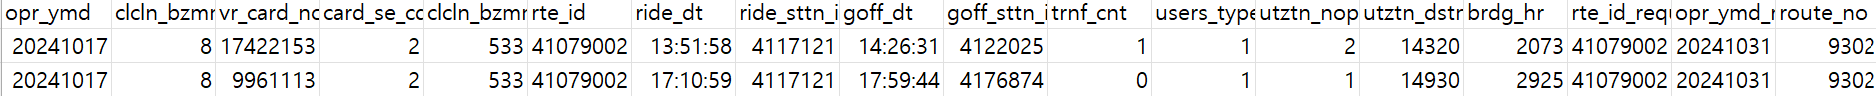

 2단계 전처리 과정에서는, 교통카드 데이터에 포함된 승·하차 정류장 ID(ride_sttn_id, goff_sttn_id)가 모두 숫자로 암호화되어 있다는 점을 해결하기 위해 다음과 같은 절차를 수행하였다.
우선 교통카드빅데이터시스템에서 해당 ID를 이용해 정류장 한글 명칭을 복원하고, 이후 이 명칭을 기반으로 국토부 정류장 좌표 데이터와 매칭하여 승·하차 정류장의 명칭, 정류장 순번, 좌표 정보를 포함한 통합 테이블을 구축하였다.
이 과정을 통해 이후 분석 단계에서 노선별 공간적 특성과 지역 생활권 분석이 가능하도록 기초 공간데이터셋을 완성하였다.

### 2. **정류장 id를 이용한 정류장 위치 및 정류장 한글화 하기**

In [ ]:
import pandas as pd
demand_df_path = r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\도시 빅데이터 분석\찐 잠실\output\Jamsil_Metropolitan_Bus_demand.csv"
demand_df = pd.read_csv(demand_df_path)

C:\Users\금경훈\AppData\Local\Temp\ipykernel_15660\1657717810.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  demand_df = pd.read_csv(demand_df_path)


In [ ]:
demand_df

,opr_ymd,clcln_bzmn_id,vr_card_no,card_se_cd,clcln_bzmn_trfc_mns_cd,rte_id,ride_dt,ride_sttn_id,ride_sttn_id.1,goff_dt,goff_sttn_id,goff_sttn_id.1,trnf_cnt,users_type_cd,utztn_nope,utztn_dstnc,brdg_hr,rte_id_request
0,20240919,8,9312640,2,533,41079002,21:58:29,미사역,4122023,22:27:15,잠실광역환승센터,4117121,0,1,1,14830,1726,41079002
1,20240919,8,60966449,2,533,41079002,9:17:43,하남풍산역.덕풍지구대,4118704,9:23:50,스타필드하남,4118620,0,1,1,2010,367,41079002
2,20240919,8,54635810,1,533,41079002,21:43:08,잠실광역환승센터,4117121,22:12:56,센트리버.스타힐스.더샵리버포레,4121873,1,1,1,12820,1788,41079002
3,20240919,8,67621590,2,533,41079002,6:31:49,미사강변2차푸르지오.센트리버,4121870,6:57:57,잠실광역환승센터,4117121,0,1,1,12940,1568,41079002
4,20240919,8,67621590,2,533,41079002,21:45:28,잠실광역환승센터,4117121,22:12:02,미사강변리버스위트칸타빌.리슈빌,4121872,1,1,1,12500,1594,41079002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43684,20240919,8,10607011,2,533,41046020,22:07:33,잠실광역환승센터,4117121,22:39:12,9122616,9122616,1,1,1,19440,1899,41046020
43685,20240919,8,55743107,2,533,41046020,13:33:49,잠실광역환승센터,4117121,13:59:56,범데미.갈매더샵,4177328,0,1,1,17910,1567,41046020
43686,20240919,8,52066227,2,533,41046020,6:34:22,갈매더샵아파트.갈매6단지,4122694,7:20:41,잠실광역환승센터,4117121,0,1,1,19200,2779,41046020
43687,20240919,8,5713584,1,533,41046020,17:26:23,잠실광역환승센터,4117121,17:47:43,범데미.갈매더샵,4177328,0,1,1,17910,1280,41046020


### 교통카드 빅데이터 정류장정보  api https://stcis.go.kr/wps/openapi/devsvc/openApiDevView.do+ 국토교통부 정류장 위치 https://www.data.go.kr/data/15067528/fileData.do = 노선별 상행, 하행 구분 및 정류장 id 한글화

In [ ]:
# -*- coding: utf-8 -*-
import re
import ast
import time
import requests
import pandas as pd
from tqdm import tqdm
from urllib.parse import quote

# =========================================================
# 0) 노선 검색 로그 텍스트 → DataFrame 파싱
# =========================================================
text = """
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=9302] → status=OK count=1
  ▶ {'rte_id': '41079002', 'routeNo': '9302', 'stgSttnNma': 'BRT공영버스차고지(미정차)', 'arrSttnNma': '하남시버스환승공영차고지.검단산입구'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1003] → status=OK count=1
  ▶ {'rte_id': '41005169', 'routeNo': '1003', 'stgSttnNma': '다산차고지', 'arrSttnNma': '모두랑근린공원.다산진건데시앙'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2353] → status=OK count=1
  ▶ {'rte_id': '41005904', 'routeNo': 'M2353', 'stgSttnNma': '차고지대기(미정차)', 'arrSttnNma': '다산자이폴라리스.다산자이'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2323] → status=OK count=1
  ▶ {'rte_id': '41002906', 'routeNo': 'M2323', 'stgSttnNma': '호평동차고지', 'arrSttnNma': '호평동차고지'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1000-1] → status=OK count=1
  ▶ {'rte_id': '41002484', 'routeNo': '1000-1', 'stgSttnNma': '호평동차고지', 'arrSttnNma': '호평동차고지'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2352] → status=OK count=1
  ▶ {'rte_id': '41005903', 'routeNo': 'M2352', 'stgSttnNma': '호평동차고지(미정차)', 'arrSttnNma': '호평동차고지(미정차)'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1000] → status=OK count=4
  ▶ {'rte_id': '41002085', 'routeNo': '1000', 'stgSttnNma': '호평동차고지', 'arrSttnNma': '호평동차고지'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1200] → status=OK count=3
  ▶ {'rte_id': '41005131', 'routeNo': '1200', 'stgSttnNma': '차산리', 'arrSttnNma': '차산리'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2316] → status=OK count=1
  ▶ {'rte_id': '41002904', 'routeNo': 'M2316', 'stgSttnNma': '영남아파트.풍림아이원아파트', 'arrSttnNma': '영남아파트.풍림아이원아파트'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=8002] → status=OK count=1
  ▶ {'rte_id': '41005133', 'routeNo': '8002', 'stgSttnNma': '대성리', 'arrSttnNma': '대성리'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2341] → status=OK count=1
  ▶ {'rte_id': '41005901', 'routeNo': 'M2341', 'stgSttnNma': '대성리차고지(미정차)', 'arrSttnNma': '대성리차고지(미정차)'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=8012] → status=OK count=1
  ▶ {'rte_id': '41077013', 'routeNo': '8012', 'stgSttnNma': '광릉내', 'arrSttnNma': '광릉내'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1001] → status=OK count=2
  ▶ {'rte_id': '41005145', 'routeNo': '1001', 'stgSttnNma': '청학리', 'arrSttnNma': '청학리'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2344] → status=NOT_FOUND count=None
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1115-6] → status=OK count=1
  ▶ {'rte_id': '41002051', 'routeNo': '1115-6', 'stgSttnNma': '농수산물시장', 'arrSttnNma': '농수산물시장'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1009] → status=OK count=1
  ▶ {'rte_id': '41003010', 'routeNo': '1009', 'stgSttnNma': '수원대학교', 'arrSttnNma': '수원대학교'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=2301] → status=OK count=1
  ▶ {'rte_id': '41009284', 'routeNo': '2301', 'stgSttnNma': '문호리종점', 'arrSttnNma': '문호리종점'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=500-1] → status=OK count=1
  ▶ {'rte_id': '41002058', 'routeNo': '500-1', 'stgSttnNma': '동원대학교', 'arrSttnNma': '동원대학교'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=32] → status=OK count=8
  ▶ {'rte_id': '41003005', 'routeNo': '32', 'stgSttnNma': '추자동차고지입구', 'arrSttnNma': 'HY인터내셔널'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=31] → status=OK count=13
  ▶ {'rte_id': '41079003', 'routeNo': '31', 'stgSttnNma': '감일스윗시티1단지.단독주택1단지', 'arrSttnNma': '감일스윗시티1단지.단독주택1단지'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1007] → status=OK count=1
  ▶ {'rte_id': '41003009', 'routeNo': '1007', 'stgSttnNma': '수원대학교', 'arrSttnNma': '수원대학교'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G1300] → status=OK count=1
  ▶ {'rte_id': '41059026', 'routeNo': 'G1300', 'stgSttnNma': '덕정차고지', 'arrSttnNma': '덕정차고지'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=3006] → status=OK count=1
  ▶ {'rte_id': '41041117', 'routeNo': '3006', 'stgSttnNma': '경복대.포천캠퍼스입구', 'arrSttnNma': '경복대.포천캠퍼스입구'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G6000] → status=OK count=2
  ▶ {'rte_id': '41040143', 'routeNo': 'G6000', 'stgSttnNma': '민락동종점(미정차)', 'arrSttnNma': '민락동종점(미정차)'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G6100] → status=OK count=1
  ▶ {'rte_id': '41040147', 'routeNo': 'G6100', 'stgSttnNma': '민락동종점(미정차)', 'arrSttnNma': '경기도청북부청사'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G6009] → status=OK count=1
  ▶ {'rte_id': '41086025', 'routeNo': 'G6009', 'stgSttnNma': '호수자이파밀리에.아이원', 'arrSttnNma': '아이원.호수자이파밀리에'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1304] → status=OK count=1
  ▶ {'rte_id': '41059031', 'routeNo': '1304', 'stgSttnNma': '홍죽산단근린공원', 'arrSttnNma': '홍죽산단근린공원'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G2100] → status=OK count=1
  ▶ {'rte_id': '41109001', 'routeNo': 'G2100', 'stgSttnNma': '이천역', 'arrSttnNma': '이천역종점'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G9311] → status=OK count=1
  ▶ {'rte_id': '41107001', 'routeNo': 'G9311', 'stgSttnNma': '용문터미널', 'arrSttnNma': '용문터미널'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1680] → status=OK count=1
  ▶ {'rte_id': '41046016', 'routeNo': '1680', 'stgSttnNma': '갈매역', 'arrSttnNma': '갈매역'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G1690] → status=OK count=1
  ▶ {'rte_id': '41046020', 'routeNo': 'G1690', 'stgSttnNma': '갈매역', 'arrSttnNma': '한라비발디후문'}
"""

data = []
for line in text.strip().splitlines():
    if line.startswith('['):
        url_match = re.search(r'\[(.*?)\]', line)
        status_match = re.search(r'status=(\w+)', line)
        count_match = re.search(r'count=(\d+)', line)
        if url_match and status_match and count_match:
            url = url_match.group(1)
            status = status_match.group(1)
            count = int(count_match.group(1))
            data.append({'URL': url, 'Status': status, 'Count': count})
    elif line.strip().startswith('▶'):
        # 안전하게 literal_eval 사용
        info = ast.literal_eval(line.strip(' ▶ '))
        data[-1].update(info)

Bus_route_information_df = pd.DataFrame(data)

# =========================================================
# 1) 노선번호 → 경기도 시군구 매핑 병합 (gg_ctpv_cd=41 고정)
#    1680, G1690은 '구리'로 덮어쓰기(뒤에 오는 키가 최종)
# =========================================================
ROUTE_TO_SGG = {
    # 하남시 (41450)
    "9302":   ("41450","하남시"),
    "9302-1": ("41450","하남시"),
    "G9311":  ("41450","하남시"),

    # 남양주시 (41360)
    "1003":   ("41360","남양주시"),
    "1000-1": ("41360","남양주시"),
    "M2323":  ("41360","남양주시"),
    "M2353":  ("41360","남양주시"),
    "M2352":  ("41360","남양주시"),
    "1000":   ("41360","남양주시"),
    "1200":   ("41360","남양주시"),
    "1200-1": ("41360","남양주시"),
    "M2316":  ("41360","남양주시"),
    "8002":   ("41360","남양주시"),
    "M2341":  ("41360","남양주시"),
    "8012":   ("41360","남양주시"),
    "1001":   ("41360","남양주시"),
    "G1300":  ("41630","양주시"),
    "1304":   ("41630","양주시"),

    # 구리시(우선 적용)
    "1680":   ("41310","구리시"),
    "G1690":  ("41310","구리시"),

    # 안양시 (41170)
    "M5333":  ("41170","안양시"),

    # 구리시 (41310)
    "1115-6": ("41310","구리시"),

    # 수원시 (41110)
    "P5342":  ("41110","수원시"),

    # 화성시 (41590)
    "G6009":  ("41590","화성시"),
    "P9301":  ("41590","화성시"),
    "P9302":  ("41590","화성시"),
    "1009":   ("41590","화성시"),
    "1007":   ("41590","화성시"),

    # 양평군 (41830)
    "2301":   ("41830","양평군"),

    # 광주시 (41610)
    "500-1":  ("41610","광주시"),
    "500-1A": ("41610","광주시"),

    # 위례신도시 → 하남시 처리
    "31":     ("41450","하남시"),

    # 의정부시 (41150)
    "G6000":  ("41150","의정부시"),
    "G6100":  ("41150","의정부시"),

    # 이천시 (41500)
    "G2100":  ("41500","이천시"),

    # 포천시 (41650)
    "3006":   ("41650","포천시"),

    # 동두천시 (41250)
    "P9701":  ("41250","동두천시"),
}

map_df = pd.DataFrame([
    {"routeNo": rno, "gg_ctpv_cd": "41", "gg_sgg_cd": cd, "gg_sgg_nm": nm}
    for rno, (cd, nm) in ROUTE_TO_SGG.items()
])

out_df = Bus_route_information_df.merge(map_df, on="routeNo", how="left")

# =========================================================
# 2) 상세 정류장 목록 API 수집 (노선ID + 시군구코드)
#    apis.data.go.kr 버스 정류장 세부 (페이지네이션 완주)
#    * 네가 준 인증키로 고정 *
#    * 개발 편의: HTTP(80) 사용, JSON 대문자 키 맞춤 *
# =========================================================
SERVICE_KEY_RAW = ""  # <- 네가 준 키
SERVICE_KEY = quote(SERVICE_KEY_RAW, safe="")  # 혹시 모를 특수문자 대비
BASE_URL = "http://apis.data.go.kr/1613000/BusRoutespecificStopInformation/getBusRoutespecificStopInformation"

def get_all_bus_stops(out_df, service_key):
    unique_routes = out_df[['rte_id', 'gg_sgg_cd']].dropna().drop_duplicates()
    all_data = []

    print(f"총 {len(unique_routes)}개 노선 처리 시작...")

    for _, row in tqdm(unique_routes.iterrows(), total=len(unique_routes), desc="노선 처리중"):
        route_id = str(row['rte_id'])
        sgg_cd = str(int(row['gg_sgg_cd'])) if pd.notna(row['gg_sgg_cd']) else None
        if not sgg_cd:
            print(f"[SKIP] sgg_cd 없음: route_id={route_id}")
            continue

        page = 1
        route_total_data = []

        while True:
            params = {
                'serviceKey': service_key,
                'pageNo': str(page),
                'numOfRows': '100',
                'opr_ymd': '20250806',   # 운행일자(필요 시 교체)
                'rte_id': route_id,
                'ctpv_cd': '41',
                'sgg_cd': sgg_cd,
                'dataType': 'JSON'
            }

            try:
                resp = requests.get(BASE_URL, params=params, timeout=30)
                if resp.status_code != 200:
                    print(f"  HTTP {resp.status_code} 오류 (route_id={route_id}, page={page})")
                    break

                data = resp.json()

                if 'Response' in data:
                    body = data['Response'].get('body', {})
                    if page == 1:
                        print(f"route_id={route_id} sgg_cd={sgg_cd} → totalCount={body.get('totalCount', 0)}")

                    items = body.get('items', {})
                    item_list = items.get('item', []) if isinstance(items, dict) else []

                    if isinstance(item_list, dict):
                        item_list = [item_list]

                    if not item_list:
                        if page == 1:
                            print("  데이터 없음")
                        break

                    route_total_data.extend(item_list)
                    # 마지막 페이지 판정: 받은 게 100 미만이면 마지막
                    if len(item_list) < 100:
                        break
                    page += 1
                    time.sleep(0.1)
                else:
                    print(f"  응답 구조 오류: {data}")
                    break

            except Exception as e:
                print(f"  에러: {e}")
                break

        if route_total_data:
            all_data.extend(route_total_data)

    if all_data:
        df = pd.DataFrame(all_data)
        df.to_csv('bus_route_details_full.csv', index=False, encoding='utf-8-sig')
        print(f"\n✅ 저장 완료: 총 {len(df)}개 정류장 데이터 (bus_route_details_full.csv)")
        if 'rte_id' in df.columns:
            print("📊 노선별 정류장 수(Top10):")
            print(df['rte_id'].value_counts().head(10))
        return df
    else:
        print("❌ 수집된 데이터가 없습니다.")
        return pd.DataFrame()

bus_route_details_df = get_all_bus_stops(out_df, SERVICE_KEY)

총 29개 노선 처리 시작...


노선 처리중:   3%|▎         | 1/29 [00:00<00:23,  1.19it/s]

route_id=41079002 sgg_cd=41450 → totalCount=38


노선 처리중:   7%|▋         | 2/29 [00:01<00:18,  1.42it/s]

route_id=41005169 sgg_cd=41360 → totalCount=58


노선 처리중:  10%|█         | 3/29 [00:01<00:15,  1.71it/s]

route_id=41005904 sgg_cd=41360 → totalCount=19


노선 처리중:  14%|█▍        | 4/29 [00:02<00:13,  1.83it/s]

route_id=41002906 sgg_cd=41360 → totalCount=25


노선 처리중:  17%|█▋        | 5/29 [00:02<00:12,  1.98it/s]

route_id=41002484 sgg_cd=41360 → totalCount=36


노선 처리중:  21%|██        | 6/29 [00:03<00:10,  2.11it/s]

route_id=41005903 sgg_cd=41360 → totalCount=22


노선 처리중:  24%|██▍       | 7/29 [00:03<00:10,  2.17it/s]

route_id=41002085 sgg_cd=41360 → totalCount=70


노선 처리중:  28%|██▊       | 8/29 [00:04<00:09,  2.10it/s]

route_id=41005131 sgg_cd=41360 → totalCount=88


노선 처리중:  31%|███       | 9/29 [00:04<00:09,  2.08it/s]

route_id=41002904 sgg_cd=41360 → totalCount=25


노선 처리중:  34%|███▍      | 10/29 [00:05<00:08,  2.15it/s]

route_id=41005133 sgg_cd=41360 → totalCount=31


노선 처리중:  38%|███▊      | 11/29 [00:05<00:08,  2.11it/s]

route_id=41005901 sgg_cd=41360 → totalCount=22


노선 처리중:  41%|████▏     | 12/29 [00:06<00:07,  2.18it/s]

route_id=41077013 sgg_cd=41360 → totalCount=30


노선 처리중:  45%|████▍     | 13/29 [00:06<00:07,  2.24it/s]

route_id=41005145 sgg_cd=41360 → totalCount=62


노선 처리중:  48%|████▊     | 14/29 [00:06<00:06,  2.32it/s]

route_id=41002051 sgg_cd=41310 → totalCount=47


노선 처리중:  52%|█████▏    | 15/29 [00:07<00:05,  2.34it/s]

route_id=41003010 sgg_cd=41590 → totalCount=17


노선 처리중:  55%|█████▌    | 16/29 [00:07<00:05,  2.37it/s]

route_id=41009284 sgg_cd=41830 → totalCount=7


노선 처리중:  59%|█████▊    | 17/29 [00:08<00:04,  2.41it/s]

route_id=41002058 sgg_cd=41610 → totalCount=66


노선 처리중:  62%|██████▏   | 18/29 [00:08<00:04,  2.41it/s]

route_id=41079003 sgg_cd=41450 → totalCount=36


노선 처리중:  66%|██████▌   | 19/29 [00:08<00:04,  2.36it/s]

route_id=41003009 sgg_cd=41590 → totalCount=17


노선 처리중:  69%|██████▉   | 20/29 [00:09<00:03,  2.38it/s]

route_id=41059026 sgg_cd=41630 → totalCount=27


노선 처리중:  72%|███████▏  | 21/29 [00:09<00:03,  2.38it/s]

route_id=41041117 sgg_cd=41650 → totalCount=40


노선 처리중:  76%|███████▌  | 22/29 [00:10<00:02,  2.45it/s]

route_id=41040143 sgg_cd=41150 → totalCount=29


노선 처리중:  79%|███████▉  | 23/29 [00:10<00:02,  2.21it/s]

route_id=41040147 sgg_cd=41150 → totalCount=28


노선 처리중:  83%|████████▎ | 24/29 [00:11<00:02,  2.17it/s]

route_id=41086025 sgg_cd=41590 → totalCount=22


노선 처리중:  86%|████████▌ | 25/29 [00:11<00:01,  2.09it/s]

route_id=41059031 sgg_cd=41630 → totalCount=19


노선 처리중:  90%|████████▉ | 26/29 [00:12<00:01,  1.57it/s]

route_id=41109001 sgg_cd=41500 → totalCount=17


노선 처리중:  93%|█████████▎| 27/29 [00:13<00:01,  1.79it/s]

route_id=41107001 sgg_cd=41450 → totalCount=2


노선 처리중:  97%|█████████▋| 28/29 [00:13<00:00,  1.96it/s]

route_id=41046016 sgg_cd=41310 → totalCount=26


노선 처리중: 100%|██████████| 29/29 [00:13<00:00,  2.09it/s]

route_id=41046020 sgg_cd=41310 → totalCount=22

✅ 저장 완료: 총 948개 정류장 데이터 (bus_route_details_full.csv)
📊 노선별 정류장 수(Top10):
rte_id
41005131    88
41002085    70
41002058    66
41005145    62
41005169    58
41002051    47
41041117    40
41079002    38
41002484    36
41079003    36
Name: count, dtype: int64


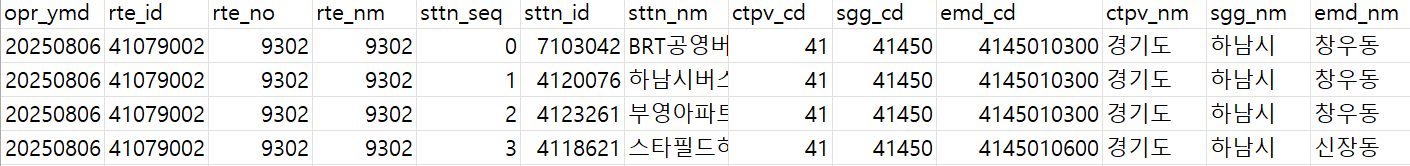

opr_ymd: 데이터 기준일

rte_id: 노선 고유 ID

rte_no: 대중이 보는 실제 노선번호

rte_nm: 노선명

sttn_seq: 노선 내 정류장 순번(0 = 출발지).

sttn_id: 정류장 고유 ID(국토부 정류장 코드).

sttn_nm: 정류장 이름(한글).

ctpv_cd: 시·도 코드(예: 41 = 경기도).

sgg_cd: 시·군·구 코드(행정구역 코드).

emd_cd: 읍면동 코드(행정동 고유 번호).

ctpv_nm: 시·도 이름(예: 경기도).

sgg_nm: 시·군·구 이름(예: 하남시).

emd_nm: 읍면동 이름(예: 창우동).

### 국토부 정류장 위치정보 이용하여 정류장 위치 매칭

In [ ]:
# =========================================================
# 3) 정류장 위치 CSV와 조인 (정류장명 기준)
#    - 경기도만 필터링 후 조인
#    - 경로 예시는 9302 정렬 출력
# =========================================================
stops_fp = r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\도시 빅데이터 분석\찐 잠실\국토교통부_전국 버스정류장 위치정보_20241028.csv"
details_fp = r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\도시 빅데이터 분석\찐 잠실\output\bus_route_details_full.csv" # 방금 저장한 파일

# 인코딩: 공공데이터 엑셀/CSV는 cp949가 편함
버스정류장_위치정보_df = pd.read_csv(stops_fp, encoding='cp949')
bus_route_details_df = pd.read_csv(details_fp, encoding='utf-8')

경기도_정류장_df = 버스정류장_위치정보_df[버스정류장_위치정보_df['도시명'].str.contains('경기도', na=False)]
print(f"경기도 정류장 수: {len(경기도_정류장_df)}")

merged_df = pd.merge(
    bus_route_details_df,
    경기도_정류장_df,
    left_on='sttn_nm',   # API 정류장명
    right_on='정류장명',   # 위치정보 정류장명
    how='inner'
)

print(f"매칭된 데이터: {len(merged_df)}개")
print("\n매칭 결과 샘플:")
print(merged_df[['rte_id', 'rte_no', 'sttn_seq', 'sttn_nm', '위도', '경도']].head())

# 특정 노선(예: 9302) 경로 확인
route_9302 = merged_df[merged_df['rte_no'] == '9302'].sort_values('sttn_seq')
print("\n[9302 경로]")
print(route_9302[['sttn_seq', 'sttn_nm', '위도', '경도']])
# === 최종 결과 저장 ===
merged_df.to_csv(
    "bus_route_details_with_coords.csv", 
    index=False, 
    encoding="utf-8-sig"
)

print(f"\n✅ 최종 저장 완료: bus_route_details_with_coords.csv ({len(merged_df)} 행)")



경기도 정류장 수: 37697
매칭된 데이터: 1481개

매칭 결과 샘플:
     rte_id rte_no  sttn_seq             sttn_nm         위도          경도
0  41079002   9302         1  하남시버스환승공영차고지.검단산입구  37.538983  127.229633
1  41079002   9302         1  하남시버스환승공영차고지.검단산입구  37.538500  127.229667
2  41079002   9302         2               부영아파트  37.694267  126.766467
3  41079002   9302         2               부영아파트  37.541333  127.226283
4  41079002   9302         2               부영아파트  37.539817  127.227950

[9302 경로]
    sttn_seq             sttn_nm         위도          경도
0          1  하남시버스환승공영차고지.검단산입구  37.538983  127.229633
1          1  하남시버스환승공영차고지.검단산입구  37.538500  127.229667
2          2               부영아파트  37.694267  126.766467
3          2               부영아파트  37.541333  127.226283
4          2               부영아파트  37.539817  127.227950
..       ...                 ...        ...         ...
66        45               부영아파트  37.007983  127.184250
67        45               부영아파트  37.263000  127.640450
68        

### 정류장 id 한글정류장 맞추기

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd

# ===== 파일 경로 =====
demand_fp = r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\도시 빅데이터 분석\찐 잠실\output\10월평일\Jamsil_Metropolitan_Bus_demand1017.csv"
ref_fp    = r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\도시 빅데이터 분석\찐 잠실\광역버스노선최종merged_df.csv"

# ===== 0) 유틸: 시각(HH:MM:SS)로 보기 좋게 변환 =====
def to_hhmmss(x: str) -> str:
    if pd.isna(x):
        return x
    x = str(x).strip()
    # 이미 "HH:MM:SS"면 그대로
    if ":" in x and len(x.split(":")) == 3:
        return x
    # 20241024HHMMSS 또는 HHMMSS 형태 처리
    digits = "".join(ch for ch in x if ch.isdigit())
    # 뒤 6자리가 HHMMSS
    if len(digits) >= 6:
        hhmmss = digits[-6:]
        return f"{hhmmss[0:2]}:{hhmmss[2:4]}:{hhmmss[4:6]}"
    return x

# ===== 1) 데이터 불러오기 =====
demand = pd.read_csv(demand_fp, dtype=str)
ref    = pd.read_csv(ref_fp, dtype=str)

# 공백 정리
demand = demand.apply(lambda s: s.str.strip() if s.dtype == "object" else s)
ref    = ref.apply(lambda s: s.str.strip() if s.dtype == "object" else s)

# ===== 2) 참조 테이블 필요한 컬럼만 =====
# (노선ID, 노선명, 정류장ID, 정류장명, 정류장순서, 정류장X위치값, 정류장Y위치값, 읍면동명)
need_cols = ["노선ID","노선명","정류장ID","정류장명","정류장순서","정류장X위치값","정류장Y위치값","읍면동명"]
missing = [c for c in need_cols if c not in ref.columns]
if missing:
    raise ValueError(f"참조파일에 필요한 컬럼이 없습니다: {missing}")

ref = ref[need_cols].drop_duplicates()

# ===== 3) 승차 정류장 매핑 (rte_id + ride_sttn_id ↔ 노선ID + 정류장ID) =====
ride_merged = demand.merge(
    ref,
    left_on=["rte_id", "ride_sttn_id"],
    right_on=["노선ID", "정류장ID"],
    how="left"
)

ride_merged = ride_merged.rename(columns={
    "노선명": "ride_노선명",
    "정류장명": "ride_sttn_id(한글)",
    "정류장순서": "ride_정류장순서",
    "정류장X위치값": "ride_X",
    "정류장Y위치값": "ride_Y",
    "읍면동명": "ride_읍면동"
})

# ===== 4) 하차 정류장 매핑 (rte_id + goff_sttn_id ↔ 노선ID + 정류장ID) =====
full_merged = ride_merged.merge(
    ref,
    left_on=["rte_id", "goff_sttn_id"],
    right_on=["노선ID", "정류장ID"],
    how="left",
    suffixes=("", "_goffref")
)

full_merged = full_merged.rename(columns={
    "노선명": "goff_노선명",
    "정류장명": "goff_sttn_id(한글)",
    "정류장순서": "goff_정류장순서",
    "정류장X위치값": "goff_X",
    "정류장Y위치값": "goff_Y",
    "읍면동명": "goff_읍면동"
})

# 병합 보조키로 들어온 right-key 컬럼 제거(남아있다면)
for col in ["노선ID_goffref", "정류장ID_goffref"]:
    if col in full_merged.columns:
        full_merged.drop(columns=[col], inplace=True)

# ===== 5) 시간 컬럼 보기 좋게(HH:MM:SS) =====
if "ride_dt" in full_merged.columns:
    full_merged["ride_dt"] = full_merged["ride_dt"].apply(to_hhmmss)
if "goff_dt" in full_merged.columns:
    full_merged["goff_dt"] = full_merged["goff_dt"].apply(to_hhmmss)

# ===== 6) 컬럼 순서(스크린샷 스타일) =====
preferred_order = [
    "opr_ymd","clcln_bzmn_id","vr_card_no","card_se_cd","clcln_bzmn_trfc_mns_cd",
    "rte_id",
    "ride_dt","ride_sttn_id(한글)","ride_sttn_id","ride_정류장순서","ride_X","ride_Y","ride_읍면동",
    "goff_dt","goff_sttn_id(한글)","goff_sttn_id","goff_정류장순서","goff_X","goff_Y","goff_읍면동"
]

# 실제 존재하는 컬럼만 순서 적용 + 나머지는 뒤에
front = [c for c in preferred_order if c in full_merged.columns]
back  = [c for c in full_merged.columns if c not in front]
full_merged = full_merged[front + back]

# ===== 7) 저장 =====
out_fp = demand_fp.replace(".csv", "_sttn_enriched.csv")
full_merged.to_csv(out_fp, index=False, encoding="utf-8-sig")
print(f"✅ 생성 완료: {out_fp}")


✅ 생성 완료: C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\도시 빅데이터 분석\찐 잠실\output\10월평일\Jamsil_Metropolitan_Bus_demand1017_sttn_enriched.csv


### 노선 id - 실제 노선 번호 매칭

In [ ]:
# -*- coding: utf-8 -*-
import re, ast
import pandas as pd

# ===== 1) 사용자 입력 텍스트 =====
text = """
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=9302] → status=OK count=1
  ▶ {'routeId': '41079002', 'routeNo': '9302', 'stgSttnNma': 'BRT공영버스차고지(미정차)', 'arrSttnNma': '하남시버스환승공영차고지.검단산입구'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1003] → status=OK count=1
  ▶ {'routeId': '41005169', 'routeNo': '1003', 'stgSttnNma': '다산차고지', 'arrSttnNma': '모두랑근린공원.다산진건데시앙'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2353] → status=OK count=1
  ▶ {'routeId': '41005904', 'routeNo': 'M2353', 'stgSttnNma': '차고지대기(미정차)', 'arrSttnNma': '다산자이폴라리스.다산자이'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2323] → status=OK count=1
  ▶ {'routeId': '41002906', 'routeNo': 'M2323', 'stgSttnNma': '호평동차고지', 'arrSttnNma': '호평동차고지'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1000-1] → status=OK count=1
  ▶ {'routeId': '41002484', 'routeNo': '1000-1', 'stgSttnNma': '호평동차고지', 'arrSttnNma': '호평동차고지'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2352] → status=OK count=1
  ▶ {'routeId': '41005903', 'routeNo': 'M2352', 'stgSttnNma': '호평동차고지(미정차)', 'arrSttnNma': '호평동차고지(미정차)'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1000] → status=OK count=4
  ▶ {'routeId': '41002085', 'routeNo': '1000', 'stgSttnNma': '호평동차고지', 'arrSttnNma': '호평동차고지'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1200] → status=OK count=3
  ▶ {'routeId': '41005131', 'routeNo': '1200', 'stgSttnNma': '차산리', 'arrSttnNma': '차산리'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2316] → status=OK count=1
  ▶ {'routeId': '41002904', 'routeNo': 'M2316', 'stgSttnNma': '영남아파트.풍림아이원아파트', 'arrSttnNma': '영남아파트.풍림아이원아파트'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=8002] → status=OK count=1
  ▶ {'routeId': '41005133', 'routeNo': '8002', 'stgSttnNma': '대성리', 'arrSttnNma': '대성리'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2341] → status=OK count=1
  ▶ {'routeId': '41005901', 'routeNo': 'M2341', 'stgSttnNma': '대성리차고지(미정차)', 'arrSttnNma': '대성리차고지(미정차)'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=8012] → status=OK count=1
  ▶ {'routeId': '41077013', 'routeNo': '8012', 'stgSttnNma': '광릉내', 'arrSttnNma': '광릉내'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1001] → status=OK count=2
  ▶ {'routeId': '41005145', 'routeNo': '1001', 'stgSttnNma': '청학리', 'arrSttnNma': '청학리'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=M2344] → status=NOT_FOUND count=None
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1115-6] → status=OK count=1
  ▶ {'routeId': '41002051', 'routeNo': '1115-6', 'stgSttnNma': '농수산물시장', 'arrSttnNma': '농수산물시장'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1009] → status=OK count=1
  ▶ {'routeId': '41003010', 'routeNo': '1009', 'stgSttnNma': '수원대학교', 'arrSttnNma': '수원대학교'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=2301] → status=OK count=1
  ▶ {'routeId': '41009284', 'routeNo': '2301', 'stgSttnNma': '문호리종점', 'arrSttnNma': '문호리종점'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=500-1] → status=OK count=1
  ▶ {'routeId': '41002058', 'routeNo': '500-1', 'stgSttnNma': '동원대학교', 'arrSttnNma': '동원대학교'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=32] → status=OK count=8
  ▶ {'routeId': '41003005', 'routeNo': '32', 'stgSttnNma': '추자동차고지입구', 'arrSttnNma': 'HY인터내셔널'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=31] → status=OK count=13
  ▶ {'routeId': '41079003', 'routeNo': '31', 'stgSttnNma': '감일스윗시티1단지.단독주택1단지', 'arrSttnNma': '감일스윗시티1단지.단독주택1단지'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1007] → status=OK count=1
  ▶ {'routeId': '41003009', 'routeNo': '1007', 'stgSttnNma': '수원대학교', 'arrSttnNma': '수원대학교'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G1300] → status=OK count=1
  ▶ {'routeId': '41059026', 'routeNo': 'G1300', 'stgSttnNma': '덕정차고지', 'arrSttnNma': '덕정차고지'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=3006] → status=OK count=1
  ▶ {'routeId': '41041117', 'routeNo': '3006', 'stgSttnNma': '경복대.포천캠퍼스입구', 'arrSttnNma': '경복대.포천캠퍼스입구'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G6000] → status=OK count=2
  ▶ {'routeId': '41040143', 'routeNo': 'G6000', 'stgSttnNma': '민락동종점(미정차)', 'arrSttnNma': '민락동종점(미정차)'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G6100] → status=OK count=1
  ▶ {'routeId': '41040147', 'routeNo': 'G6100', 'stgSttnNma': '민락동종점(미정차)', 'arrSttnNma': '경기도청북부청사'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G6009] → status=OK count=1
  ▶ {'routeId': '41086025', 'routeNo': 'G6009', 'stgSttnNma': '호수자이파밀리에.아이원', 'arrSttnNma': '아이원.호수자이파밀리에'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1304] → status=OK count=1
  ▶ {'routeId': '41059031', 'routeNo': '1304', 'stgSttnNma': '홍죽산단근린공원', 'arrSttnNma': '홍죽산단근린공원'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G2100] → status=OK count=1
  ▶ {'routeId': '41109001', 'routeNo': 'G2100', 'stgSttnNma': '이천역', 'arrSttnNma': '이천역종점'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G9311] → status=OK count=1
  ▶ {'routeId': '41107001', 'routeNo': 'G9311', 'stgSttnNma': '용문터미널', 'arrSttnNma': '용문터미널'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=1680] → status=OK count=1
  ▶ {'routeId': '41046016', 'routeNo': '1680', 'stgSttnNma': '갈매역', 'arrSttnNma': '갈매역'}
[https://stcis.go.kr/openapi/busroute.json?apikey=20250923221711e90aad32sj5otmrcildup89g3b&sdCd=41&routeNo=G1690] → status=OK count=1
  ▶ {'routeId': '41046020', 'routeNo': 'G1690', 'stgSttnNma': '갈매역', 'arrSttnNma': '한라비발디후문'}
"""

# ===== 2) routeNo ↔ routeId 매핑 추출 =====
# "▶ {...}" 라인에서 dict를 파싱
matches = re.findall(r"▶ (.*?)\n", text)
route_no_to_id = {}
for m in matches:
    try:
        d = ast.literal_eval(m.strip())
        rn = str(d.get("routeNo", "")).strip()
        rid = str(d.get("routeId", "")).strip()
        if rn and rid:
            route_no_to_id[rn] = rid
    except Exception:
        pass

# 역방향 매핑: routeId -> routeNo
id_to_route_no = {v: k for k, v in route_no_to_id.items()}

print("매핑 수 (routeNo→routeId):", len(route_no_to_id))
print("매핑 수 (routeId→routeNo):", len(id_to_route_no))

# ===== 3) CSV 불러오기 =====
csv_fp = r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\도시 빅데이터 분석\찐 잠실\output\10월평일\Jamsil_Metropolitan_Bus_demand1017.csv"
df = pd.read_csv(csv_fp, dtype=str)

# 공백 정리
df = df.apply(lambda s: s.str.strip() if s.dtype == "object" else s)

# ===== 4) join 기준 판단 =====
# 케이스 A) '노선번호'가 있으면 그대로 route_id를 붙임
if "노선번호" in df.columns:
    df["route_id"] = df["노선번호"].map(route_no_to_id)

# 케이스 B) '노선번호'가 없고 'rte_id'가 있으면 역매핑으로 route_no를 붙임
elif "rte_id" in df.columns:
    df["route_no"] = df["rte_id"].map(id_to_route_no)

# (참고) 다른 이름일 수 있는 경우 대비
else:
    # 후보 컬럼 자동 탐색
    candidates_id = [c for c in df.columns if c.lower().strip() in {"rte_id","route_id"} or "rte_id" in c.lower()]
    candidates_no = [c for c in df.columns if "노선" in c or "route_no" in c.lower() or "routeno" in c.lower()]
    raise ValueError(
        f"'노선번호'도 'rte_id'도 없습니다. 후보 확인 → "
        f"route_id 후보: {candidates_id}, route_no 후보: {candidates_no}\n"
        f"실제 컬럼: {list(df.columns)}"
    )

# ===== 5) 불필요 'Unnamed:' 컬럼 제거(있으면)
drop_cols = [c for c in df.columns if c.startswith("Unnamed:")]
if drop_cols:
    df = df.drop(columns=drop_cols)

# ===== 6) 저장(덮어쓰기)
df.to_csv(csv_fp, index=False, encoding="utf-8-sig")
print(f"✅ 컬럼 추가 및 저장 완료: {csv_fp}")


2024.10.17 잠실광역환승센터 탑승 건수는 아래 사진 처럼 테이블이 만들어짐


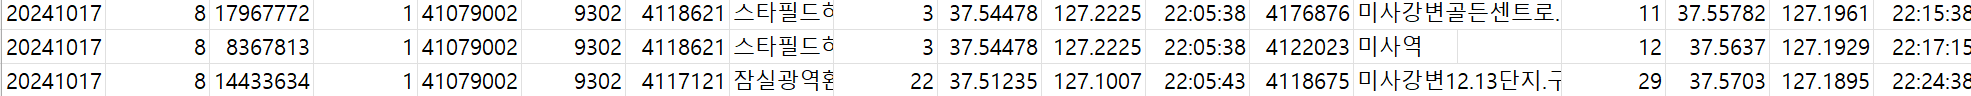

opr_ymd: 교통카드 승차가 발생한 날짜(YYYYMMDD).

clcln_bzmn_id: 거래를 정산하는 사업자 코드(예: 8=한국스마트카드).

vr_card_no: 익명 처리된 가상 카드 번호(동일 사용자를 구분하는 ID).

utztn_nope: 이용 인원수(대부분 1).

rte_id: 노선 고유 ID(기관 내부 코드).

route_no: 실제 대중이 보는 노선번호(예: 9302).

ride_sttn_id: 승차 정류장 ID(국토부 정류장 코드).

ride_sttn_id(한글): 승차 정류장명(한글).

ride_정류장순서: 해당 노선 내 정류장 순번.

ride_정류장X: 승차 정류장 경도(Longitude).

ride_정류장Y: 승차 정류장 위도(Latitude).

ride_dt: 승차 시각(HH:MM:SS).

goff_sttn_id: 하차 정류장 ID(국토부 정류장 코드).

goff_sttn_id(한글): 하차 정류장명(한글).

goff_정류장순서: 노선 내 하차 정류장 순번.

goff_정류장X: 하차 정류장 경도(Longitude).

goff_정류장Y: 하차 정류장 위도(Latitude).

goff_dt: 하차 시각(HH:MM:SS).

---------------------------------------------------------------------------------------------

### 단순회귀분석 결과

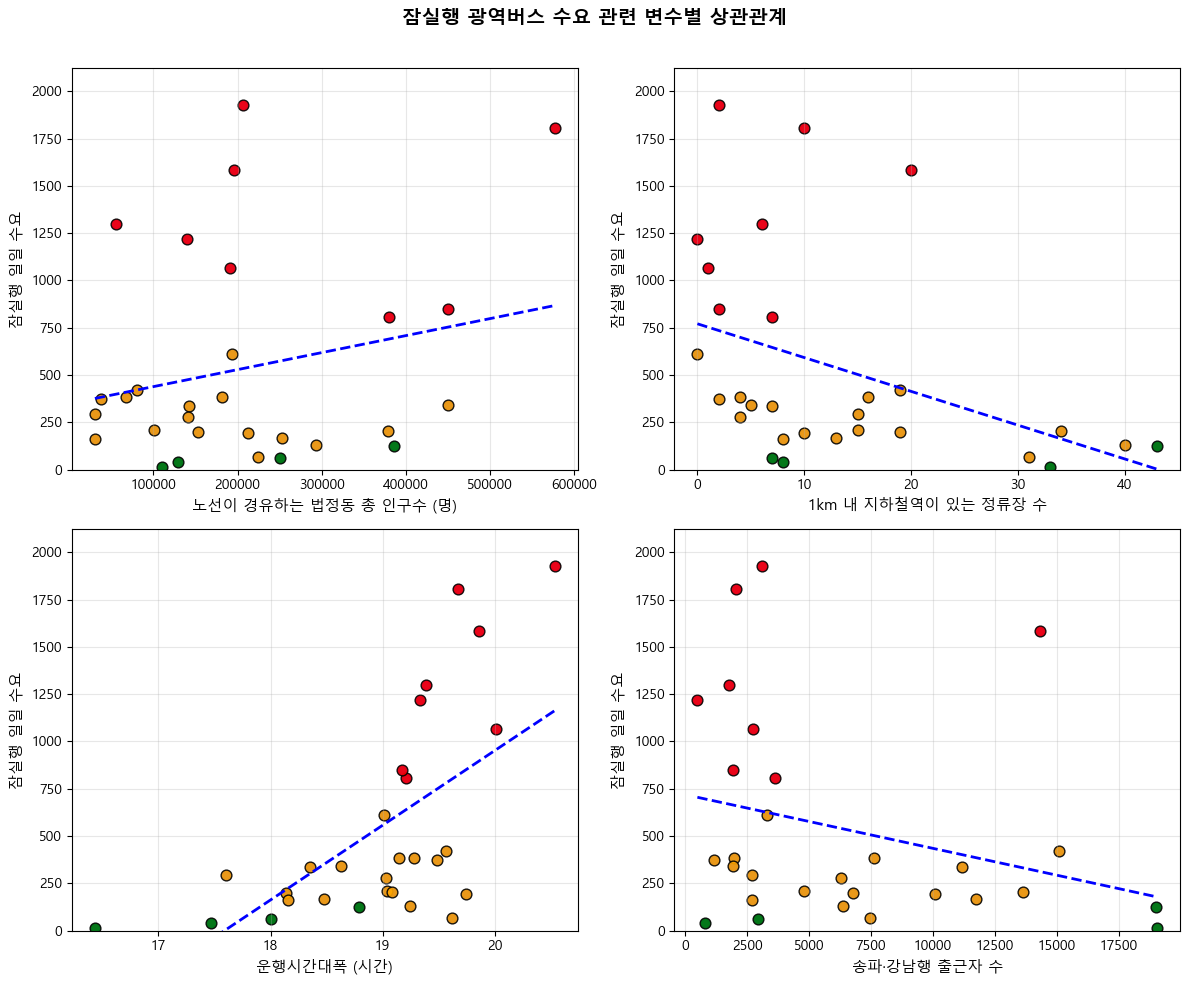

In [10]:
# -*- coding: utf-8 -*-
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr
import matplotlib.font_manager as fm

# ===== 한글 폰트 설정 =====
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# ===== 파일 로드 =====
fp = r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\도시 빅데이터 분석\찐 잠실\output\10월평일\10.17 최종파일\생활이동\금경훈_회귀분석통합본_출근포함.csv"
df = pd.read_csv(fp, encoding='utf-8-sig')

# ===== 숫자형 변환 =====
for c in ['size','POP','within_1km_cnt','운행시간대폭(시간)','출근_건수']:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(',','', regex=False), errors='coerce')

# ===== 색상 구분 =====
top_routes = ['9302','8002','G1300','M2323','3006','G6000','M2316','8012']
low_routes = ['32','1000-1','G9311','500-1']

def get_color(route):
    if route in top_routes:
        return 'red'
    elif route in low_routes:
        return 'green'
    else:
        return 'orange'

df['color'] = df['route_no'].apply(get_color)

# ===== 그래프 설정 =====
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2x2 배열로 4개 그래프
plt.subplots_adjust(hspace=0.35, wspace=0.25)      # 그래프 간 간격 조정

# ===== 변수 목록 및 라벨 =====
var_list = [
    ('POP', '노선이 경유하는 법정동 총 인구수 (명)'),
    ('within_1km_cnt', '1km 내 지하철역이 있는 정류장 수'),
    ('운행시간대폭(시간)', '운행시간대폭 (시간)'),
    ('출근_건수', '송파·강남행 출근자 수')
]

# ===== 각 그래프 생성 =====
for ax, (var, label) in zip(axes.flat, var_list):
    sns.regplot(
        x=df[var],
        y=df['size'],
        scatter=True,
        ci=None,
        color='blue',
        line_kws={'lw':2, 'ls':'--'},
        ax=ax
    )

    # 색상별로 점 찍기
    for color in ['red','orange','green']:
        subset = df[df['color']==color]
        ax.scatter(subset[var], subset['size'], c=color, s=60, edgecolor='k', alpha=0.9)

    # y축 0부터 통일
    ax.set_ylim(0, df['size'].max() * 1.1)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('잠실행 일일 수요', fontsize=11)
    ax.grid(alpha=0.3)

# ===== 전체 제목 =====
fig.suptitle('잠실행 광역버스 수요 관련 변수별 상관관계', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])  # 제목 공간 확보
plt.show()


### 3개변수 다중회귀분석 결과

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


📊 변수별 상관계수:
               변수      r  p-value
0             POP  0.230  0.23098
1  within_1km_cnt -0.400  0.03178
2      운행시간대폭(시간)  0.617  0.00036

📈 다중회귀 결과
                            OLS Regression Results                            
Dep. Variable:                   size   R-squared:                       0.480
Model:                            OLS   Adj. R-squared:                  0.417
Method:                 Least Squares   F-statistic:                     7.686
Date:                Mon, 08 Dec 2025   Prob (F-statistic):           0.000837
Time:                        15:32:19   Log-Likelihood:                -214.13
No. Observations:                  29   AIC:                             436.3
Df Residuals:                      25   BIC:                             441.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t    

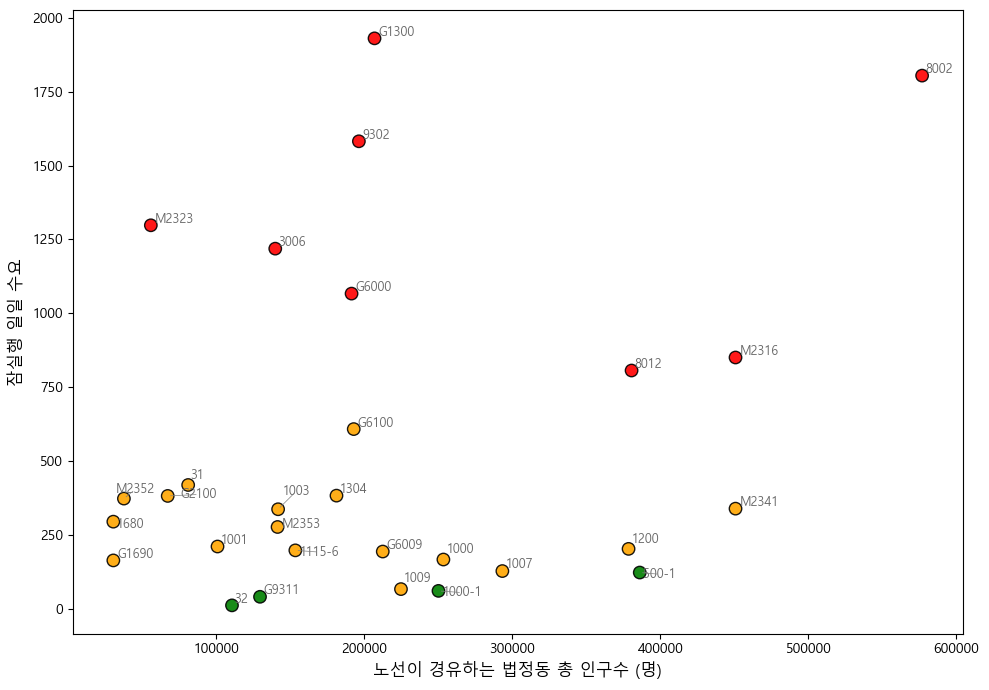

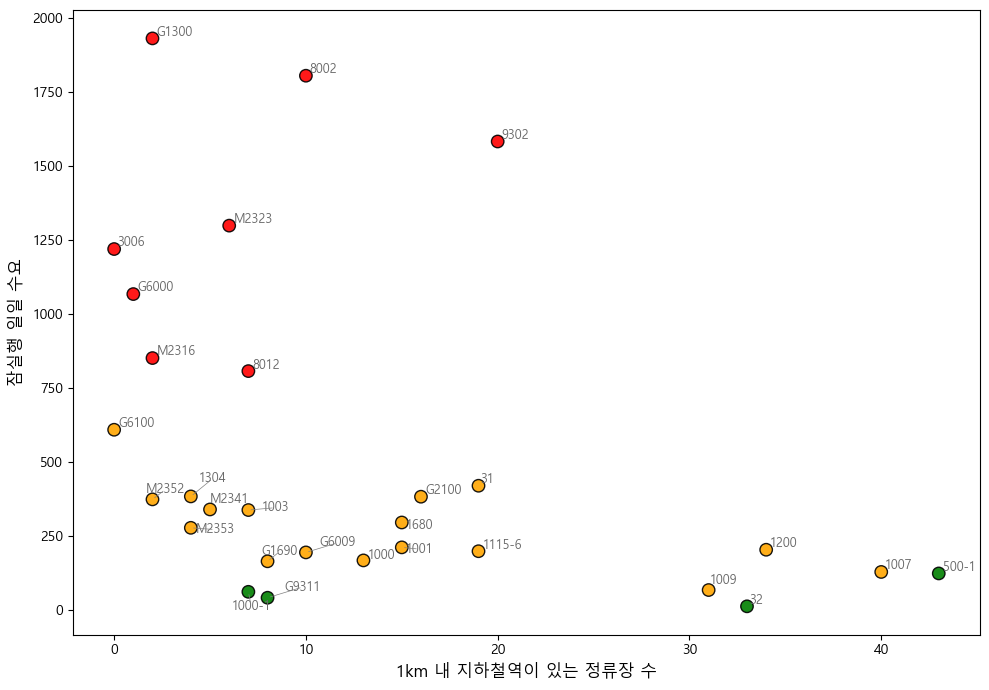

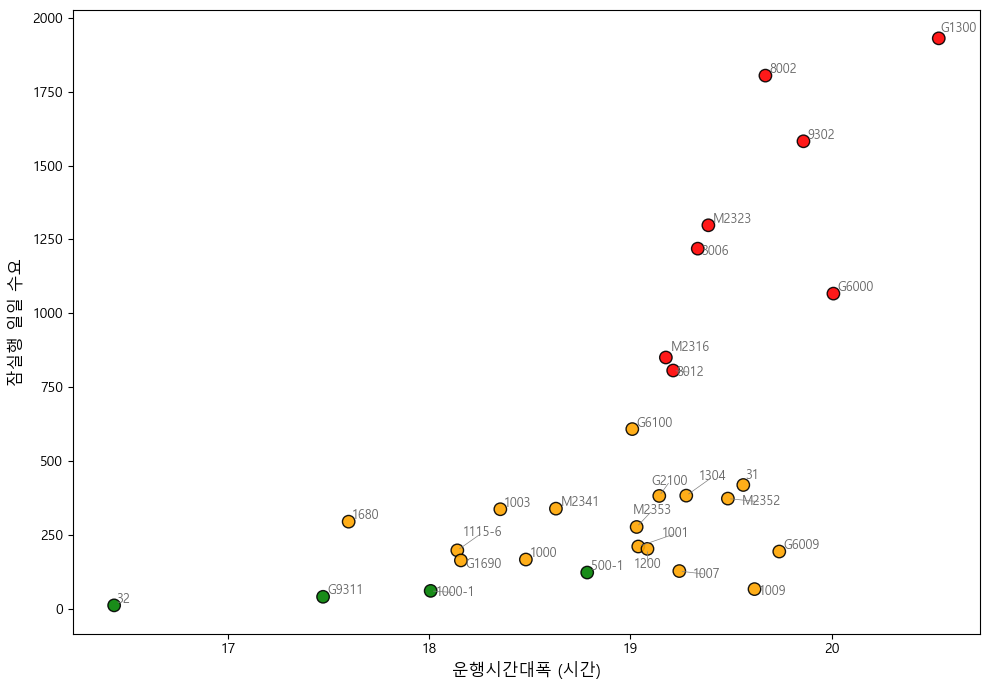

In [1]:
# -*- coding: utf-8 -*-
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr
from adjustText import adjust_text 
# ===== 한글 폰트 설정 =====
plt.rc('font', family='Malgun Gothic')  # Windows 환경
plt.rcParams['axes.unicode_minus'] = False

# ===== 파일 로드 =====
fp = r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\도시 빅데이터 분석\찐 잠실\output\10월평일\10.17 최종파일\금경훈_회귀분석통합본.csv"
df = pd.read_csv(fp, encoding='utf-8-sig')

# ===== 숫자형 변환 =====
for c in ['size','POP','within_1km_cnt','운행시간대폭(시간)']:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(',','', regex=False), errors='coerce')

# ===== 색상 구분 =====
top_routes = ['9302','8002','G1300','M2323','3006','G6000','M2316','8012']
mid_routes = ['M2352','M2341','G6100','1200','1001','1115-6','1304','1680']
low_routes = ['32','1000-1','G9311','500-1']

def get_color(route):
    if route in top_routes:
        return 'red'
    elif route in low_routes:
        return 'green'
    else:
        return 'orange'   # 중간 수요(나머지 전부)

df['color'] = df['route_no'].apply(get_color)

# ======== ① 피어슨 상관분석 ========
corr_result = []
for var in ['POP','within_1km_cnt','운행시간대폭(시간)']:
    r, p = pearsonr(df[var].dropna(), df['size'].dropna())
    corr_result.append({'변수': var, 'r': round(r,3), 'p-value': round(p,5)})

corr_df = pd.DataFrame(corr_result)
print("📊 변수별 상관계수:")
print(corr_df)

# ======== ② 다중회귀분석 ========
X = df[['POP','within_1km_cnt','운행시간대폭(시간)']]
X = sm.add_constant(X)
y = df['size']

model = sm.OLS(y, X).fit()
print("\n📈 다중회귀 결과")
print(model.summary())

# ======== ③ 시각화 함수 (adjustText 적용) ========
def scatter_plot(x_col, x_label, save_name=None):
    plt.figure(figsize=(10,7))
    plt.scatter(df[x_col], df['size'], c=df['color'], s=80, alpha=0.9, edgecolor='k')

    # ---- 라벨 겹침 방지 ----
    texts = []
    for _, row in df.iterrows():
        texts.append(
            plt.text(
                row[x_col],
                row['size'],
                row['route_no'],
                fontsize=9,
                color='dimgray'
            )
        )

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
        only_move={'points':'y', 'texts':'y'},
        force_points=0.5,
        force_text=0.5,
        expand_text=(1.05, 1.2)
    )

    plt.xlabel(x_label, fontsize=12)
    plt.ylabel('잠실행 일일 수요', fontsize=12)
    plt.tight_layout()
    plt.show()

# ======== ④ 시각화 실행 ========
scatter_plot('POP', '노선이 경유하는 법정동 총 인구수 (명)')
scatter_plot('within_1km_cnt', '1km 내 지하철역이 있는 정류장 수')
scatter_plot('운행시간대폭(시간)', '운행시간대폭 (시간)')


### 3개변수 다중공선성 평가

In [2]:
# ======== ⑤ 다중공선성(VIF) 분석 ========
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[['POP','within_1km_cnt','운행시간대폭(시간)']].copy()
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["변수"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("\n🔎 다중공선성(VIF) 분석 결과")
print(vif_data)



🔎 다중공선성(VIF) 분석 결과
               변수         VIF
0           const  564.815943
1             POP    1.096798
2  within_1km_cnt    1.093816
3      운행시간대폭(시간)    1.124290


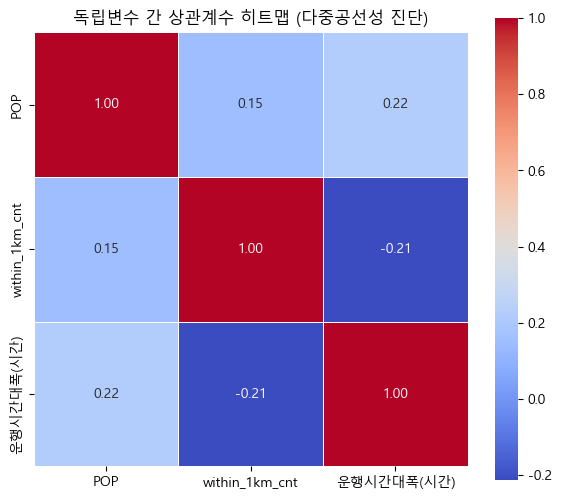

In [3]:
# ======== ⑥ 히트맵(상관계수) ========
corr_vars = ['POP','within_1km_cnt','운행시간대폭(시간)']

corr_matrix = df[corr_vars].corr()

plt.figure(figsize=(7,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.title("독립변수 간 상관계수 히트맵 (다중공선성 진단)")
plt.show()


### 4개변수 다중회귀분석

📊 변수별 상관계수:
               변수      r  p-value
0             POP  0.230  0.23098
1  within_1km_cnt -0.400  0.03178
2      운행시간대폭(시간)  0.617  0.00036
3           출근_건수 -0.285  0.13339

📈 다중회귀 결과
                            OLS Regression Results                            
Dep. Variable:                   size   R-squared:                       0.482
Model:                            OLS   Adj. R-squared:                  0.395
Method:                 Least Squares   F-statistic:                     5.577
Date:                Sun, 07 Dec 2025   Prob (F-statistic):            0.00255
Time:                        20:20:08   Log-Likelihood:                -214.07
No. Observations:                  29   AIC:                             438.1
Df Residuals:                      24   BIC:                             445.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 

C:\Users\금경훈\AppData\Local\Temp\ipykernel_29564\720396714.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


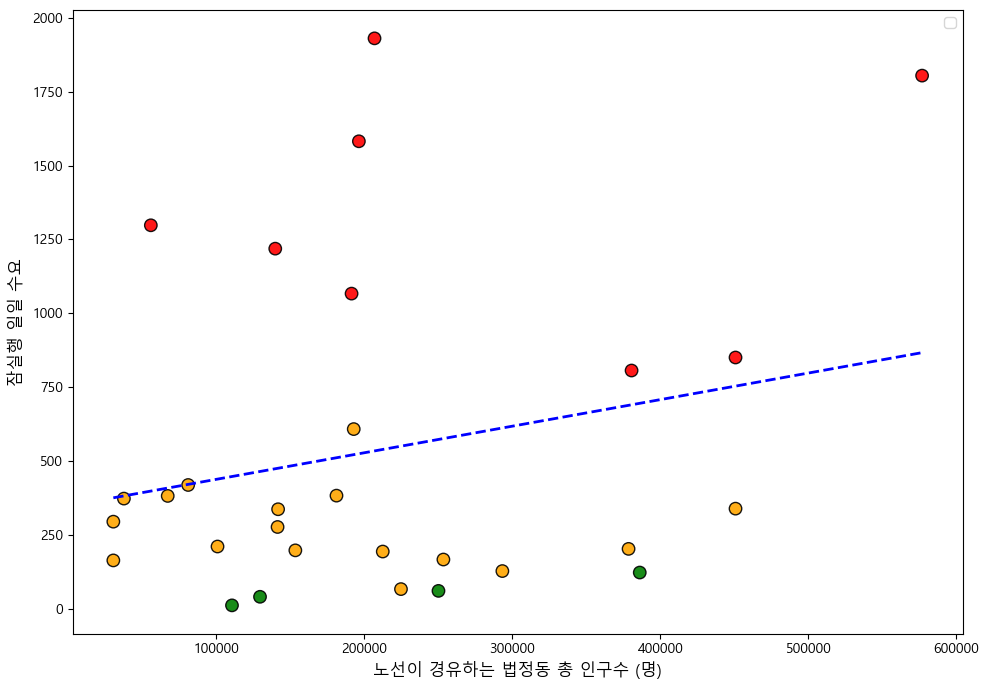

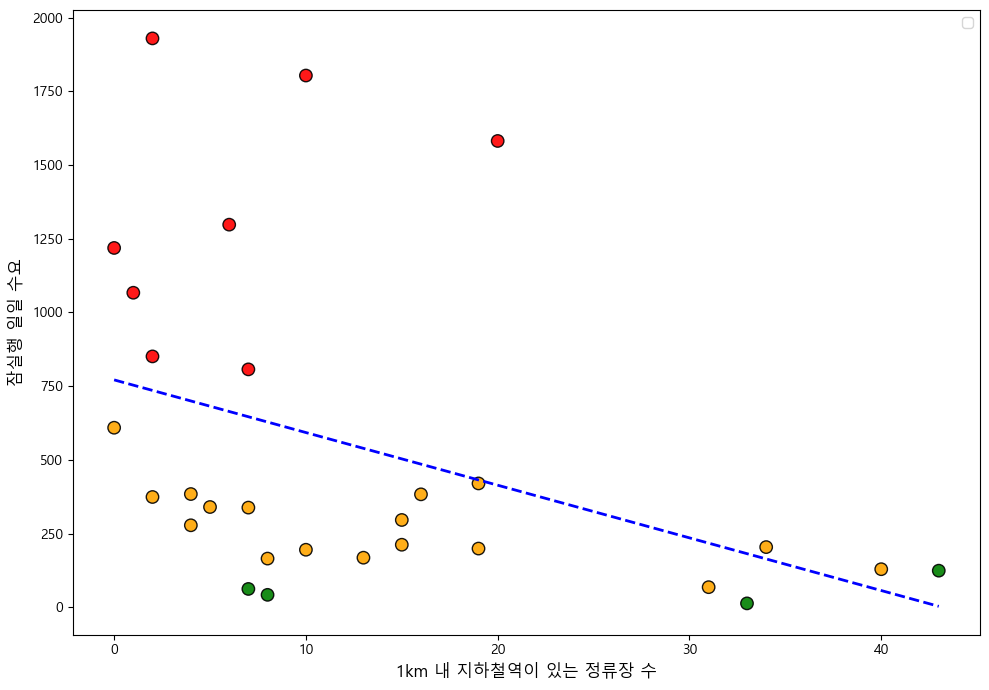

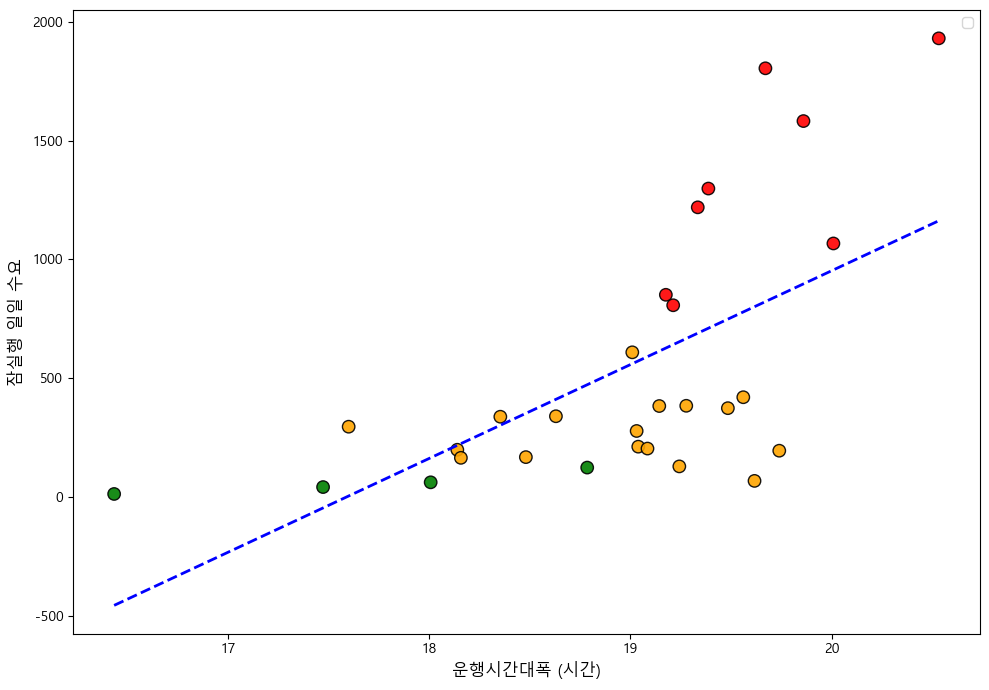

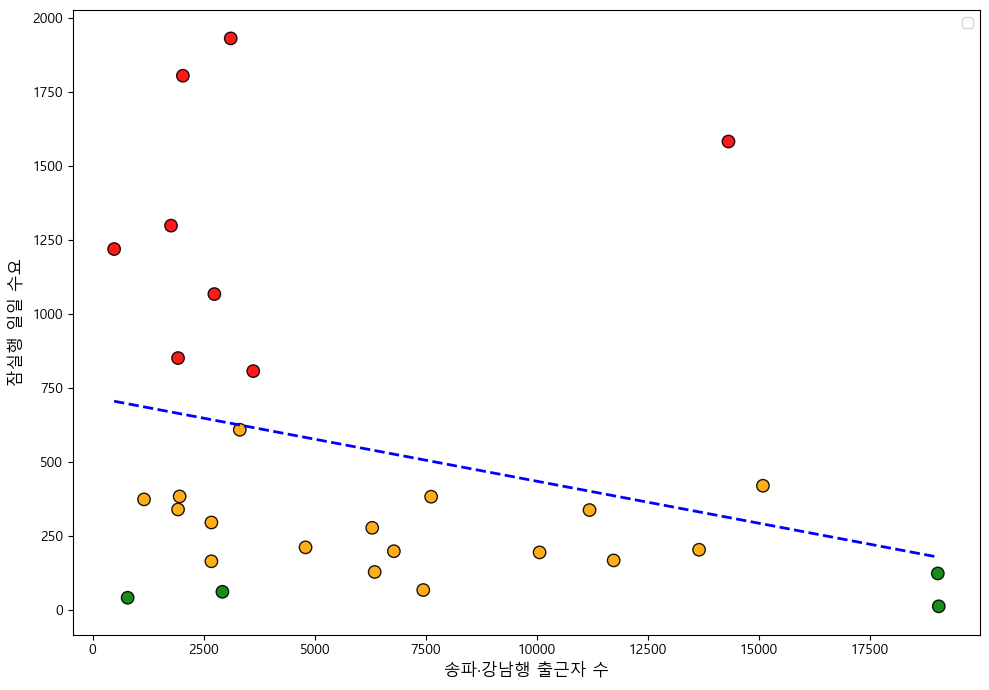

In [7]:
# -*- coding: utf-8 -*-
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr
from adjustText import adjust_text
import matplotlib.font_manager as fm

# ===== 한글 폰트 설정 =====
plt.rc('font', family='Malgun Gothic')  # Windows 환경
plt.rcParams['axes.unicode_minus'] = False

# ===== 파일 로드 =====
fp = r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\도시 빅데이터 분석\찐 잠실\output\10월평일\10.17 최종파일\생활이동\금경훈_회귀분석통합본_출근포함.csv"
df = pd.read_csv(fp, encoding='utf-8-sig')

# ===== 숫자형 변환 =====
for c in ['size','POP','within_1km_cnt','운행시간대폭(시간)','출근_건수']:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(',','', regex=False), errors='coerce')

# ===== 색상 구분 =====
top_routes = ['9302','8002','G1300','M2323','3006','G6000','M2316','8012']
low_routes = ['32','1000-1','G9311','500-1']

def get_color(route):
    if route in top_routes:
        return 'red'
    elif route in low_routes:
        return 'green'
    else:
        return 'orange'

df['color'] = df['route_no'].apply(get_color)

# ======== ① 피어슨 상관분석 (출근건수 추가) ========
corr_result = []
for var in ['POP','within_1km_cnt','운행시간대폭(시간)','출근_건수']:
    r, p = pearsonr(df[var].dropna(), df['size'].dropna())
    corr_result.append({'변수': var, 'r': round(r,3), 'p-value': round(p,5)})

corr_df = pd.DataFrame(corr_result)
print("📊 변수별 상관계수:")
print(corr_df)

# ======== ② 다중회귀분석 (출근건수 포함) ========
X = df[['POP','within_1km_cnt','운행시간대폭(시간)','출근_건수']]
X = sm.add_constant(X)
y = df['size']

model = sm.OLS(y, X).fit()
print("\n📈 다중회귀 결과")
print(model.summary())

# ======== ③ 시각화 함수 ========
def scatter_plot(x_col, x_label, save_name=None):
    plt.figure(figsize=(10,7))

    # ---- 산점도 ----
    plt.scatter(df[x_col], df['size'], c=df['color'], s=80, alpha=0.9, edgecolor='k')

    # ---- 회귀선(추세선) 추가 ----
    sns.regplot(
    x=df[x_col],
    y=df['size'],
    scatter=False,
    color='blue',
    line_kws={'lw': 2, 'ls': '--', 'label': '추세선'},
    ci=None   # ✅ 신뢰구간 음영 제거
)



    plt.xlabel(x_label, fontsize=12)
    plt.ylabel('잠실행 일일 수요', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ======== ④ 시각화 실행 ========
scatter_plot('POP', '노선이 경유하는 법정동 총 인구수 (명)')
scatter_plot('within_1km_cnt', '1km 내 지하철역이 있는 정류장 수')
scatter_plot('운행시간대폭(시간)', '운행시간대폭 (시간)')
scatter_plot('출근_건수', '송파·강남행 출근자 수')


### 4개변수 다중공선성 평가

In [8]:
# ======== ⑤ 다중공선성(VIF) 분석 ========
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 회귀에 사용한 독립변수(X) 다시 가져오기 (const 포함)
X_vif = df[['POP','within_1km_cnt','운행시간대폭(시간)','출근_건수']].copy()
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["변수"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("\n🔎 다중공선성(VIF) 분석 결과")
print(vif_data)



🔎 다중공선성(VIF) 분석 결과
               변수         VIF
0           const  565.760699
1             POP    1.110426
2  within_1km_cnt    2.235825
3      운행시간대폭(시간)    1.124398
4           출근_건수    2.124127


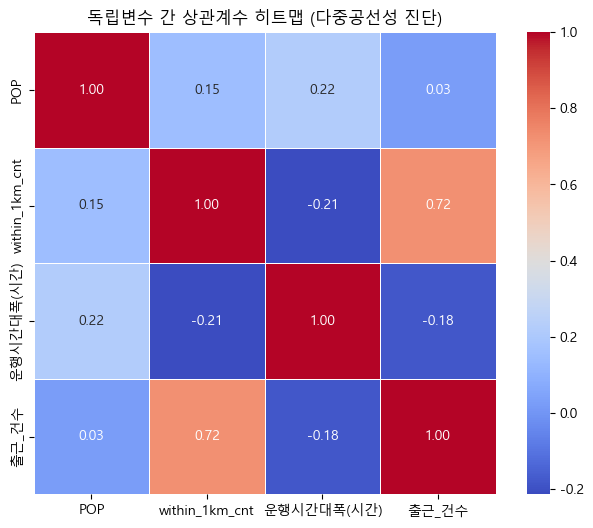

In [9]:
# ======== ⑥ 변수 간 상관행렬 히트맵 ========
import seaborn as sns
import matplotlib.pyplot as plt

corr_vars = ['POP', 'within_1km_cnt', '운행시간대폭(시간)', '출근_건수']

corr_matrix = df[corr_vars].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("독립변수 간 상관계수 히트맵 (다중공선성 진단)")
plt.show()


-----------------------------------------------------------------------------------------------

### 잠실광역버스 도착정보 구하기

잠실광역버스 ID 구하기

In [ ]:
import requests
import time

SERVICE_KEY = ""

route_numbers = [
    "1000", "1000-1", "1001", "1003", "1007", "1009", "1115-6", "1200", "1304",
    "1680", "3006", "31", "32", "500-1", "8002", "8012", "9302",
    "G1300", "G1690", "G2100", "G6000", "G6009", "G6100", "G9311",
    "M2316", "M2323", "M2341", "M2352", "M2353"
]

url = "https://apis.data.go.kr/6410000/busrouteservice/v2/getBusRouteListv2"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

results = []

for route in route_numbers:
    params = {
        "serviceKey": SERVICE_KEY,
        "keyword": route,
        "format": "json"
    }
    try:
        r = requests.get(url, params=params, headers=headers, timeout=5)
        if r.status_code == 200:
            data = r.json()
            header = data.get("response", {}).get("msgHeader", {})
            msg = header.get("resultMessage")
            if msg == "정상적으로 처리되었습니다.":
                body = data.get("response", {}).get("msgBody", {}).get("busRouteList")
                if body:
                    # busRouteList가 dict일 수도 있고 list일 수도 있음
                    if isinstance(body, dict):
                        body = [body]
                    for b in body:
                        results.append({
                            "routeName": str(b.get("routeName", "")),
                            "routeId": str(b.get("routeId", "")),
                            "regionName": b.get("regionName", ""),
                            "startStationName": b.get("startStationName", ""),
                            "endStationName": b.get("endStationName", "")
                        })
                else:
                    print(f"{route}: 결과 없음")
            else:
                print(f"{route}: 응답 비정상 ({msg})")
        else:
            print(f"{route}: 요청 실패 (Status {r.status_code})")
        time.sleep(0.3)
    except Exception as e:
        print(f"{route}: 오류 발생 → {e}")

print("\n=== 조회된 노선 목록 ===")
for r in results:
    print(f"{r['routeName']:10s} | {r['routeId']:>10s} | {r['regionName']:10s} | "
          f"{r['startStationName']} → {r['endStationName']}")



=== 조회된 노선 목록 ===
1000       |  219000013 | 고양,서울      | 대화동 → 숭례문
1000       |  221000003 | 구리,남양주,서울  | 호평동차고지 → 잠실광역환승센터
1000-1     |  234001511 | 구리,남양주,서울  | 호평동차고지 → 잠실광역환승센터
1000       |  214000244 | 안성,평택      | 기남방송 → 평택지제역
1000       |  233000077 | 수원,화성      | 장외리.오리골 → 동탄역(동측)
1000-1     |  234001511 | 구리,남양주,서울  | 호평동차고지 → 잠실광역환승센터
1001       |  218000007 | 고양,김포,부천,인천 | 고양공영차고지 → 부천대학교
1001       |  222000107 | 구리,남양주,서울  | 청학리 → 잠실광역환승센터
1003       |  222000169 | 구리,남양주,서울  | 다산차고지 → 잠실광역환승센터
G1003      |  233000328 | 서울,의왕,화성   | 현대기아연구소 → 양재역커피빈앞
1007       |  234000015 | 서울,성남,수원,화성 | 수원대학교 → 잠실광역환승센터
1007(예약)   |  233000464 | 서울,성남,수원,화성 | 수원대학교 → 잠실광역환승센터
1007-1     |  234000013 | 서울,성남,수원,용인 | 대광빌리지 → 잠실역.롯데월드
1009       |  234000310 | 서울,성남,수원,의왕,화성 | 수원대학교 → 잠실광역환승센터
1009(예약)   |  233000465 | 서울,성남,수원,의왕,화성 | 수원대학교 → 잠실광역환승센터
1115-6     |  234000031 | 구리,서울      | 농수산물시장 → 잠실광역환승센터
1200       |  216000070 | 수원,안산,화성   | 원시역1번출구 → 수원역.역전시장
1200       |  219000016

### 28개노선 (32번 폐선) 테스트

In [ ]:
import requests
import pandas as pd

# ===== 설정 =====
SERVICE_KEY = ""
STATION_ID = "123000611"  # 잠실광역환승센터

url = "https://apis.data.go.kr/6410000/busarrivalservice/v2/getBusArrivalListv2"
params = {
    "serviceKey": SERVICE_KEY,
    "stationId": STATION_ID,
    "format": "json"
}

# ===== 호출 =====
r = requests.get(url, params=params)
print("HTTP 상태 코드:", r.status_code)
print("응답 일부:", r.text[:300])  # 응답 앞부분 확인

if r.status_code == 200:
    data = r.json()
    bus_list = data["response"]["msgBody"]["busArrivalList"]

    # ===== 원하는 노선만 필터링 (28개 노선) =====
    route_filter = {
        "1000", "1000-1", "1001", "1003", "1007", "1009",
        "1115-6", "1200", "1304", "1680", "3006", "31",
        "500-1", "8002", "8012", "9302", "G1300", "G1690",
        "G2100", "G6000", "G6009", "G6100", "G9311",
        "M2316", "M2323", "M2341", "M2352", "M2353"
    }

    rows = []
    for b in bus_list:
        if b["routeName"] in route_filter:
            rows.append({
                "노선": b["routeName"],
                "첫번째 위치": b.get("stationNm1", ""),
                "도착예정(1)": b.get("predictTime1", ""),
                "두번째 위치": b.get("stationNm2", ""),
                "도착예정(2)": b.get("predictTime2", ""),
                "잔여좌석(1)": b.get("remainSeatCnt1", ""),
                "잔여좌석(2)": b.get("remainSeatCnt2", ""),
            })

    df = pd.DataFrame(rows).sort_values(by="노선")
    print("\n🚌 잠실행 버스 도착 현황 (28개 노선)")
    print(df.to_string(index=False))

else:
    print("❌ API 호출 실패:", r.text[:300])


HTTP 상태 코드: 200
응답 일부: {"response":{"comMsgHeader":"","msgHeader":{"queryTime":"2025-10-30 14:16:46.049","resultCode":0,"resultMessage":"정상적으로 처리되었습니다."},"msgBody":{"busArrivalList":[{"crowded1":"","crowded2":"","flag":"PASS","locationNo1":"","locationNo2":"","lowPlate1":"","lowPlate2":"","plateNo1":"","plateNo2":"","pred

🚌 잠실행 버스 도착 현황 (28개 노선)
    노선          첫번째 위치  도착예정(1)          두번째 위치 도착예정(2)  잔여좌석(1)  잔여좌석(2)
1000-1    올림픽대교북단(미정차)        7                               43        0
1115-6            동명빌라       14   돌다리.구리전통시장(중)      29       39       43
 500-1 문정법조단지.건영아파트(중)        8      수진리고개.태평고개      20       41       41
 G1300     잠실대교남단(미정차)        1       중랑IC(미정차)      12       21       24
 G1690       중랑IC(미정차)       12    갈매2단지.이스트힐후문      31       38       41
 G2100             가천대       17          (구)보건소      53       25       26
 G6000    올림픽대교북단(미정차)        5     동의정부IC(미정차)      24       20       23
 G6009     송파IC출입(미정차)       15      동탄테크노벨리(중)      39    

### 퇴근시간대 17~21시 2025.10.30 목 잠실 실시간 도착정보

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime

SERVICE_KEY = ""
STATION_ID = "123000611"  # 잠실광역환승센터
URL = "https://apis.data.go.kr/6410000/busarrivalservice/v2/getBusArrivalListv2"

TARGET_ROUTES = [
    "221000003", "234001511", "222000107", "222000169", "234000015", "234000310",
    "234000031", "222000078", "235000118", "221000033", "236000222", "227000017",
    "234000079", "222000084", "222000090", "227000016", "235000092", "221000035",
    "230000179", "207000099", "233000322", "207000102", "240000174", "222000105",
    "234001476", "222000179", "222000209", "222000210"
]

OUT_FILE = "jamshil_bus_log.csv"

columns = [
    "timestamp", "routeName", "routeId",
    "plateNo1", "predictTime1", "stationNm1", "remainSeatCnt1",
    "plateNo2", "predictTime2", "stationNm2", "remainSeatCnt2"
]
pd.DataFrame(columns=columns).to_csv(OUT_FILE, index=False, encoding="utf-8-sig")

START_HOUR = 17  # 17시부터
END_HOUR = 21    # 21시까지

print("🕔 잠실광역환승센터 퇴근시간대(17~21시) 실시간 수집 시작 — Ctrl+C로 중단")

try:
    while True:
        now = datetime.now()
        if START_HOUR <= now.hour < END_HOUR:
            now_str = now.strftime("%Y-%m-%d %H:%M:%S")

            try:
                r = requests.get(URL, params={
                    "serviceKey": SERVICE_KEY,
                    "stationId": STATION_ID,
                    "format": "json"
                }, timeout=10)
                data = r.json()
                buses = data["response"]["msgBody"]["busArrivalList"]
            except Exception as e:
                print(f"[{now_str}] ⚠️ 요청 실패: {e}")
                time.sleep(60)
                continue

            rows = []
            for b in buses:
                if str(b["routeId"]) in TARGET_ROUTES:
                    rows.append({
                        "timestamp": now_str,
                        "routeName": b.get("routeName", ""),
                        "routeId": b.get("routeId", ""),
                        "plateNo1": b.get("plateNo1", ""),
                        "predictTime1": b.get("predictTime1", ""),
                        "stationNm1": b.get("stationNm1", ""),
                        "remainSeatCnt1": b.get("remainSeatCnt1", ""),
                        "plateNo2": b.get("plateNo2", ""),
                        "predictTime2": b.get("predictTime2", ""),
                        "stationNm2": b.get("stationNm2", ""),
                        "remainSeatCnt2": b.get("remainSeatCnt2", "")
                    })

            if rows:
                pd.DataFrame(rows).to_csv(
                    OUT_FILE, mode="a", index=False, header=False, encoding="utf-8-sig"
                )
                print(f"[{now_str}] ✅ {len(rows)}개 노선 기록 추가됨 (퇴근시간대 수집 중)")
            else:
                print(f"[{now_str}] ⚠️ 필터된 노선 데이터 없음")

            time.sleep(60)  # 1분 간격

        else:
            print(f"[{now.strftime('%H:%M:%S')}] ⏸ 퇴근시간대 아님 — 5분 후 다시 확인")
            time.sleep(300)  # 5분마다 다시 확인

except KeyboardInterrupt:
    print("\n🛑 수집 종료 — jamshil_bus_log.csv에 저장 완료")


🕔 잠실광역환승센터 퇴근시간대(17~21시) 실시간 수집 시작 — Ctrl+C로 중단
[2025-10-30 17:00:14] ✅ 28개 노선 기록 추가됨 (퇴근시간대 수집 중)
[2025-10-30 17:01:14] ✅ 28개 노선 기록 추가됨 (퇴근시간대 수집 중)
[2025-10-30 17:02:15] ✅ 28개 노선 기록 추가됨 (퇴근시간대 수집 중)
[2025-10-30 17:03:15] ✅ 28개 노선 기록 추가됨 (퇴근시간대 수집 중)
[2025-10-30 17:04:15] ✅ 28개 노선 기록 추가됨 (퇴근시간대 수집 중)
[2025-10-30 17:05:16] ✅ 28개 노선 기록 추가됨 (퇴근시간대 수집 중)
[2025-10-30 17:06:17] ✅ 28개 노선 기록 추가됨 (퇴근시간대 수집 중)
[2025-10-30 17:07:17] ✅ 28개 노선 기록 추가됨 (퇴근시간대 수집 중)
[2025-10-30 17:08:17] ✅ 28개 노선 기록 추가됨 (퇴근시간대 수집 중)
[2025-10-30 17:09:18] ✅ 28개 노선 기록 추가됨 (퇴근시간대 수집 중)
[2025-10-30 17:10:18] ✅ 28개 노선 기록 추가됨 (퇴근시간대 수집 중)
[2025-10-30 17:11:18] ✅ 28개 노선 기록 추가됨 (퇴근시간대 수집 중)
[2025-10-30 17:12:19] ✅ 28개 노선 기록 추가됨 (퇴근시간대 수집 중)
[2025-10-30 17:13:19] ✅ 28개 노선 기록 추가됨 (퇴근시간대 수집 중)
[2025-10-30 17:14:20] ✅ 28개 노선 기록 추가됨 (퇴근시간대 수집 중)
[2025-10-30 17:15:21] ✅ 28개 노선 기록 추가됨 (퇴근시간대 수집 중)
[2025-10-30 17:16:21] ✅ 28개 노선 기록 추가됨 (퇴근시간대 수집 중)
[2025-10-30 17:17:21] ✅ 28개 노선 기록 추가됨 (퇴근시간대 수집 중)
[2025-10-30 17:18:21] ✅ 28개 노선 기록 

### 퇴근시간대 1층, 2층버스 도착정보 만들기

In [4]:
import pandas as pd

# ===== 1️⃣ 파일 불러오기 =====
fp = r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\도시 빅데이터 분석\찐 잠실\output\10월평일\10.17 최종파일\jamshil_bus_log.csv"
df = pd.read_csv(fp)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# ===== 2️⃣ 2층 버스 목록 =====
double_deckers = {
    "9302": ["75자8563","75자8495","75자8494","75자8493","75자8561","75자8562","75자8496"],
    "G1300": ["76바8142","76바8141","76바8138","76바8137"],
    "8002": ["74아3428","74아3380","74아3378","74아3374","74아3360","74아3428","74아3340",
              "74아3422","74아3337","74아3424","74아3423","74아3429","74아3405","74아3423",
              "74아3378","74아3406","74아3267"],
    "8012": ["74아3832","74아3835","74아3857"],
    "G6000": ["72바1797","72바1780"],
    "M2323": ["77바1277","77바1273"],
    "M2352": ["74아3413","74아3414"],
    "1001": ["74아3058","74아3404","74아3369","74아3403","74아3379"],
    "1003": ["74아3229","74아3266"],
    "3006": ["77아6509"],
    "G6100": ["72바1781"],
    "1009": ["77바2296","77바3606"]
}

def classify_bus_type(route, plate):
    if pd.isna(plate): return "Unknown"
    plate = str(plate).strip()
    if route in double_deckers and any(p in plate for p in double_deckers[route]):
        return "2층"
    else:
        return "1층"

df["bus_type"] = df.apply(lambda x: classify_bus_type(x["routeName"], x["plateNo1"]), axis=1)

# ===== 3️⃣ 분석할 시간대 (예: 17~21시) =====
mask = (df["timestamp"].dt.hour >= 17) & (df["timestamp"].dt.hour < 21)
df = df.loc[mask].copy()

# ===== 4️⃣ 노선별 도착 감지 =====
arrival_records = []

for route, group in df.groupby("routeName"):
    group = group.sort_values("timestamp")
    prev_plates = set()

    for t, sub in group.groupby("timestamp"):
        current_plates = set(sub["plateNo1"].dropna())
        new_plates = current_plates - prev_plates  # 새로 등장한 차량들
        for plate in new_plates:
            bus_type = classify_bus_type(route, plate)
            arrival_records.append({
                "routeName": route,
                "timestamp": t,
                "plateNo1": plate,
                "bus_type": bus_type
            })
        prev_plates = current_plates

# ===== 5️⃣ 결과 정리 =====
arrivals = pd.DataFrame(arrival_records).sort_values(["routeName", "timestamp"])
print("🚌 버스별 도착 시각 목록 (잠실 로그 기준)\n")
print(arrivals.to_string(index=False))

# ===== 6️⃣ CSV로 저장 =====
out_fp = fp.replace("jamshil_bus_log.csv", "bus_arrival_detected.csv")
arrivals.to_csv(out_fp, index=False, encoding="utf-8-sig")
print(f"\n📁 저장 완료: {out_fp}")


C:\Users\금경훈\AppData\Local\Temp\ipykernel_29564\3346118883.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")


🚌 버스별 도착 시각 목록 (잠실 로그 기준)

routeName           timestamp  plateNo1 bus_type
     1000 2030-10-25 17:00:00 경기74아1344       1층
     1000 2030-10-25 17:11:00 경기74아1386       1층
     1000 2030-10-25 17:48:00 경기74아1388       1층
     1000 2030-10-25 18:11:00 경기74아1012       1층
     1000 2030-10-25 18:29:00 경기74아1387       1층
     1000 2030-10-25 19:12:00 경기74아1385       1층
     1000 2030-10-25 19:34:00 경기74아1344       1층
     1000 2030-10-25 19:48:00 경기74아1386       1층
     1000 2030-10-25 20:37:00 경기74아1388       1층
   1000-1 2030-10-25 17:00:00 경기74아3284       1층
   1000-1 2030-10-25 17:41:00 경기74아3388       1층
   1000-1 2030-10-25 19:01:00 경기74아3284       1층
   1000-1 2030-10-25 20:22:00 경기74아3388       1층
     1001 2030-10-25 17:00:00 경기74아3058       2층
     1001 2030-10-25 17:04:00 경기74아3085       1층
     1001 2030-10-25 17:15:00 경기74아3421       1층
     1001 2030-10-25 17:29:00 경기74아3242       1층
     1001 2030-10-25 17:33:00 경기74아3248       1층
     1001 2030-10-25 17:51:00 경기74아3368   

### 비퇴근시간대 11~14시 도착정보

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime

# ============================
# 1) 기본 설정
# ============================
SERVICE_KEY = ""
STATION_ID = "123000611"  # 잠실광역환승센터
URL = "https://apis.data.go.kr/6410000/busarrivalservice/v2/getBusArrivalListv2"

# 상위 수요 8개 노선 routeId
TOP8_ROUTES = [
    "227000016",  # 9302
    "222000084",  # 8002
    "235000092",  # G1300
    "234001476",  # M2323
    "236000222",  # 3006
    "207000099",  # G6000
    "222000105",  # M2316
    "222000090"   # 8012
]

OUT_FILE = "jamshil_bus_midday_log.csv"

columns = [
    "timestamp", "routeName", "routeId",
    "plateNo1", "predictTime1", "stationNm1", "remainSeatCnt1",
    "plateNo2", "predictTime2", "stationNm2", "remainSeatCnt2"
]
pd.DataFrame(columns=columns).to_csv(OUT_FILE, index=False, encoding="utf-8-sig")

# ============================
# 2) 수집 시간대
# ============================
START_HOUR = 11
END_HOUR = 14

print("🕚 잠실광역환승센터 11~14시 비혼잡 시간대 실시간 수집 시작 — Ctrl+C로 중단")

try:
    while True:
        now = datetime.now()
        hour = now.hour

        # 11~14시에만 수집 수행
        if START_HOUR <= hour < END_HOUR:
            now_str = now.strftime("%Y-%m-%d %H:%M:%S")

            try:
                r = requests.get(URL, params={
                    "serviceKey": SERVICE_KEY,
                    "stationId": STATION_ID,
                    "format": "json"
                }, timeout=10)

                data = r.json()
                buses = data["response"]["msgBody"]["busArrivalList"]

            except Exception as e:
                print(f"[{now_str}] ⚠️ 요청 실패: {e}")
                time.sleep(30)
                continue

            rows = []
            for b in buses:
                if str(b["routeId"]) in TOP8_ROUTES:
                    rows.append({
                        "timestamp": now_str,
                        "routeName": b.get("routeName", ""),
                        "routeId": b.get("routeId", ""),
                        "plateNo1": b.get("plateNo1", ""),
                        "predictTime1": b.get("predictTime1", ""),
                        "stationNm1": b.get("stationNm1", ""),
                        "remainSeatCnt1": b.get("remainSeatCnt1", ""),
                        "plateNo2": b.get("plateNo2", ""),
                        "predictTime2": b.get("predictTime2", ""),
                        "stationNm2": b.get("stationNm2", ""),
                        "remainSeatCnt2": b.get("remainSeatCnt2", "")
                    })

            if rows:
                pd.DataFrame(rows).to_csv(
                    OUT_FILE, mode="a", index=False, header=False, encoding="utf-8-sig"
                )
                print(f"[{now_str}] ✅ {len(rows)}개 노선 기록 저장됨 (11~14시 수집)")
            else:
                print(f"[{now_str}] ⚠️ 해당 시간에 TOP8 노선 도착정보 없음")

            time.sleep(60)  # 1분 간격 수집

        else:
            print(f"[{now.strftime('%H:%M:%S')}] ⏸ 11~14시 아님 — 자동 종료")
            break

except KeyboardInterrupt:
    print("\n🛑 강제 종료됨 — jamshil_bus_midday_log.csv에 저장 완료")


🕚 잠실광역환승센터 11~14시 비혼잡 시간대 실시간 수집 시작 — Ctrl+C로 중단
[2025-11-17 11:02:05] ✅ 8개 노선 기록 저장됨 (11~14시 수집)
[2025-11-17 11:03:06] ✅ 8개 노선 기록 저장됨 (11~14시 수집)
[2025-11-17 11:04:06] ✅ 8개 노선 기록 저장됨 (11~14시 수집)
[2025-11-17 11:05:08] ✅ 8개 노선 기록 저장됨 (11~14시 수집)
[2025-11-17 11:06:09] ✅ 8개 노선 기록 저장됨 (11~14시 수집)
[2025-11-17 11:07:10] ✅ 8개 노선 기록 저장됨 (11~14시 수집)
[2025-11-17 11:08:11] ✅ 8개 노선 기록 저장됨 (11~14시 수집)
[2025-11-17 11:09:11] ✅ 8개 노선 기록 저장됨 (11~14시 수집)
[2025-11-17 11:10:12] ✅ 8개 노선 기록 저장됨 (11~14시 수집)
[2025-11-17 11:11:13] ✅ 8개 노선 기록 저장됨 (11~14시 수집)
[2025-11-17 11:12:14] ✅ 8개 노선 기록 저장됨 (11~14시 수집)
[2025-11-17 11:13:14] ✅ 8개 노선 기록 저장됨 (11~14시 수집)
[2025-11-17 11:14:15] ✅ 8개 노선 기록 저장됨 (11~14시 수집)
[2025-11-17 11:15:15] ✅ 8개 노선 기록 저장됨 (11~14시 수집)
[2025-11-17 11:16:16] ✅ 8개 노선 기록 저장됨 (11~14시 수집)
[2025-11-17 11:17:17] ✅ 8개 노선 기록 저장됨 (11~14시 수집)
[2025-11-17 11:18:17] ✅ 8개 노선 기록 저장됨 (11~14시 수집)
[2025-11-17 11:19:18] ✅ 8개 노선 기록 저장됨 (11~14시 수집)
[2025-11-17 11:20:18] ✅ 8개 노선 기록 저장됨 (11~14시 수집)
[2025-11-17 11:21:19

### 비퇴근시간대 1층, 2층 버스 도착정보 만들기

In [ ]:
import pandas as pd

# ===== 1️⃣ 파일 불러오기 =====
fp = r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\도시 빅데이터 분석\찐 잠실\output\10월평일\10.17 최종파일\jamshil_bus_midday_log.csv"
df = pd.read_csv(fp, encoding="utf-8-sig")
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# ===== 2️⃣ 2층 버스 목록 =====
double_deckers = {
    "9302": ["75자8563","75자8495","75자8494","75자8493","75자8561","75자8562","75자8496"],
    "G1300": ["76바8142","76바8141","76바8138","76바8137"],
    "8002": ["74아3428","74아3380","74아3378","74아3374","74아3360","74아3428","74아3340",
              "74아3422","74아3337","74아3424","74아3423","74아3429","74아3405","74아3423",
              "74아3378","74아3406","74아3267"],
    "8012": ["74아3832","74아3835","74아3857"],
    "G6000": ["72바1797","72바1780"],
    "M2323": ["77바1277","77바1273"],
    "M2352": ["74아3413","74아3414"],
    "1001": ["74아3058","74아3404","74아3369","74아3403","74아3379"],
    "1003": ["74아3229","74아3266"],
    "3006": ["77아6509"],
    "G6100": ["72바1781"],
    "1009": ["77바2296","77바3606"]
}

def classify_bus_type(route, plate):
    if pd.isna(plate):
        return "Unknown"
    plate = str(plate).strip()
    if route in double_deckers and any(p in plate for p in double_deckers[route]):
        return "2층"
    else:
        return "1층"

# plateNo1 기준으로 타입 분류
df["bus_type"] = df.apply(lambda x: classify_bus_type(x["routeName"], x["plateNo1"]), axis=1)

# ===== 3️⃣ 분석할 시간대 (예: 11~14시) =====
mask = (df["timestamp"].dt.hour >= 11) & (df["timestamp"].dt.hour < 14)
df = df.loc[mask].copy()

# ===== 4️⃣ 노선별 새로 등장한 차량만 감지 =====
arrival_records = []

for route, group in df.groupby("routeName"):
    group = group.sort_values("timestamp")
    prev_plates = set()

    for t, sub in group.groupby("timestamp"):
        current_plates = set(sub["plateNo1"].dropna())
        new_plates = current_plates - prev_plates  # 새로 등장한 차량
        for plate in new_plates:
            arrival_records.append({
                "routeName": route,
                "timestamp": t,
                "plateNo1": plate,
                "bus_type": classify_bus_type(route, plate)
            })
        prev_plates = current_plates

# ===== 5️⃣ DataFrame 정리 =====
arrivals = pd.DataFrame(arrival_records).sort_values(["routeName", "timestamp"])

print("🚌 버스별 최초 도착 감지 기록 (11~14시)\n")
print(arrivals.to_string(index=False))

# ===== 6️⃣ CSV 저장 =====
out_fp = fp.replace("jamshil_bus_midday_log.csv", "bus_arrival_detected_midday.csv")
arrivals.to_csv(out_fp, index=False, encoding="utf-8-sig")
print(f"\n📁 저장 완료: {out_fp}")


🚌 버스별 최초 도착 감지 기록 (11~14시)

routeName           timestamp  plateNo1 bus_type
     3006 2025-11-17 11:02:05 경기72바1049       1층
     3006 2025-11-17 11:08:11 경기77아6513       1층
     3006 2025-11-17 11:12:14 경기77아6586       1층
     3006 2025-11-17 11:27:22 경기77아6514       1층
     3006 2025-11-17 11:41:31 경기77아6352       1층
     3006 2025-11-17 11:52:36 경기77아6509       2층
     3006 2025-11-17 12:07:42 경기77아6353       1층
     3006 2025-11-17 12:22:49 경기77아6354       1층
     3006 2025-11-17 12:39:57 경기77아6587       1층
     3006 2025-11-17 12:51:01 경기77아6355       1층
     3006 2025-11-17 13:06:07 경기77아6441       1층
     3006 2025-11-17 13:28:17 경기77아6442       1층
     3006 2025-11-17 13:42:24 경기77아6588       1층
     8002 2025-11-17 11:02:05 경기74아3377       1층
     8002 2025-11-17 11:12:14 경기74아3386       1층
     8002 2025-11-17 11:16:16 경기74아3374       2층
     8002 2025-11-17 11:20:18 경기74아3086       1층
     8002 2025-11-17 11:34:27 경기74아3380       2층
     8002 2025-11-17 11:38:29 경기74아3355  

10월 17일 잠실광역버스 수요로  노선·시간대별 승객 수요 에다가 실제 도착한 퇴근시간대 1층/2층 버스 로그를 엮어서 총 좌석 공급량과 좌석 부족량을 계산하고, 그 결과를 demand_supply_current.csv로 저장하는 분석 

In [8]:
import pandas as pd
from pathlib import Path

# ===== 경로 설정 =====
DIR = r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\도시 빅데이터 분석\찐 잠실\output\10월평일\10.17 최종파일"
fp_demand = Path(DIR, "demand_by_hour.csv")             # route_no,time_bin,demand
fp_arrival = Path(DIR, "bus_arrival_detected.csv")      # routeName,timestamp,plateNo1,bus_type
fp_out     = Path(DIR, "demand_supply_current.csv")

# ===== 1) 데이터 로드 =====
dem = pd.read_csv(fp_demand, dtype={"route_no": str, "time_bin": str})
arr = pd.read_csv(fp_arrival, dtype=str)
# ======================================
# plate number 컬럼 자동 탐색
# ======================================
possible_plate_cols = ['plateNo1','plateNo','plate_no','bus_plate','vehicleNo','plateNumber','plate_no1']

real_plate_col = None
for col in possible_plate_cols:
    if col in arr.columns:
        real_plate_col = col
        break

if real_plate_col is None:
    raise ValueError(f"plate 번호 컬럼을 찾을 수 없습니다. CSV 컬럼 목록: {arr.columns.tolist()}")

# 표준 이름으로 통일
arr = arr.rename(columns={real_plate_col: "plateNo1"})

# 열 이름 통일
dem = dem.rename(columns={"route_no": "routeName"})
required_cols_dem = {"routeName","time_bin","demand"}
required_cols_arr = {"routeName","timestamp","bus_type"}
missing_dem = required_cols_dem - set(dem.columns)
missing_arr = required_cols_arr - set(arr.columns)
if missing_dem:
    raise ValueError(f"demand_by_hour.csv에 필요한 컬럼 없음: {missing_dem}")
if missing_arr:
    raise ValueError(f"bus_arrival_detected.csv에 필요한 컬럼 없음: {missing_arr}")

# ===== 2) 도착 로그 → 시간대(time_bin) 만들기 =====
# timestamp 포맷 경고 방지: 네 파일이 'YYYY-MM-DD HH:MM:SS' 형태라 가정
arr["timestamp"] = pd.to_datetime(arr["timestamp"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
if arr["timestamp"].isna().any():
    # 혹시 다른 포맷 섞이면 fallback로 한 번 더 시도
    arr.loc[arr["timestamp"].isna(), "timestamp"] = pd.to_datetime(arr.loc[arr["timestamp"].isna(), "timestamp"], errors="coerce")

# 시간대 문자열: "HH:00-HH+1:00"
def to_timebin(ts):
    if pd.isna(ts): 
        return None
    h = ts.hour
    return f"{h:02d}:00-{(h+1)%24:02d}:00"

arr["time_bin"] = arr["timestamp"].map(to_timebin)

# ===== 3) 1층/2층 카운트 및 좌석 환산 =====
# 버스 층수 표준화
arr["bus_type"] = arr["bus_type"].str.strip()

# 시간대별·노선별 1층/2층 대수
pivot = (arr.dropna(subset=["time_bin"])
           .groupby(["routeName","time_bin","bus_type"])
           .size()
           .unstack(fill_value=0))

# 컬럼명 보정: 없으면 0으로 채우기
for col in ["1층","2층"]:
    if col not in pivot.columns:
        pivot[col] = 0

pivot = pivot.reset_index().rename(columns={"1층":"num_1층","2층":"num_2층"})

# 좌석수(1층=44, 2층=70)
pivot["seat_1층"] = pivot["num_1층"] * 44
pivot["seat_2층"] = pivot["num_2층"] * 70
pivot["total_seat"] = pivot["seat_1층"] + pivot["seat_2층"]

# ===== 4) 수요와 머지 → 부족좌석 계산 =====
cur = pd.merge(dem, pivot, on=["routeName","time_bin"], how="left")

# NaN → 0 (해당 시간대 도착 로그가 없으면 0대로)
for c in ["num_1층","num_2층","seat_1층","seat_2층","total_seat"]:
    cur[c] = cur[c].fillna(0).astype(int)

cur["seat_gap"] = cur["total_seat"] - cur["demand"]   # (공급 - 수요, 음수면 부족)
cur["seat_shortage"] = cur["demand"] - cur["total_seat"]
cur["seat_shortage"] = cur["seat_shortage"].clip(lower=0)  # 부족만 양수로

# ===== 5) 저장 + 요약 출력 =====
cur = cur.sort_values(["routeName","time_bin"]).reset_index(drop=True)
cur.to_csv(fp_out, index=False, encoding="utf-8-sig")

print("📁 저장 완료:", fp_out)
# 부족 있는 구간 상위 10개 미리보기
print(cur.loc[cur["seat_shortage"]>0, ["routeName","time_bin","demand","num_1층","num_2층","total_seat","seat_shortage"]].head(10))

# 노선별/시간대별 요약(선택)
summary = (cur.groupby(["routeName","time_bin"], as_index=False)
             .agg(demand=("demand","sum"),
                  buses=("total_seat", lambda x: int(x.sum()/44) if x.sum()>0 else 0),  # 대략적 환산(참고용)
                  total_seat=("total_seat","sum"),
                  shortage=("seat_shortage","sum")))
print("\n=== 요약 미리보기 ===")
print(summary.head(12))


📁 저장 완료: C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\도시 빅데이터 분석\찐 잠실\output\10월평일\10.17 최종파일\demand_supply_current.csv
   routeName     time_bin  demand  num_1층  num_2층  total_seat  seat_shortage
5     1000-1  18:00-19:00      15       0       0           0             15
48        32  17:00-18:00       1       0       0           0              1
49        32  18:00-19:00       3       0       0           0              3
50        32  19:00-20:00       2       0       0           0              2
51        32  20:00-21:00       1       0       0           0              1
65      9302  18:00-19:00     405       2       3         298            107
69     G1300  18:00-19:00     377       2       3         298             79
71     G1300  20:00-21:00     230       5       0         220             10
92     G9311  17:00-18:00       2       0       0           0              2
95     G9311  20:00-21:00       6       0       0           0              6

=== 요약 미리보기 ===
   routeName     time_bi

### 현황 투입에 대한 버스 부족, 적정, 과잉 판단

In [5]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np

# ======================================
# 1) 파일 경로 입력
# ======================================
PATH = r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\도시 빅데이터 분석\찐 잠실\output\10월평일\10.17 최종파일\demand_supply_current.csv"

# ======================================
# 2) 데이터 로드
# ======================================
df = pd.read_csv(PATH)
df['routeName'] = df['routeName'].astype(str)

# ======================================
# 3) 주요 노선 필터링
# ======================================
main_routes = ['9302','8002','G1300','M2323','3006','G6000','M2352','8012']
df_main = df[df['routeName'].isin(main_routes)].copy()

# ======================================
# 4) 총이용률 계산
# ======================================
df_main['총이용률'] = np.where(df_main['total_seat'] > 0,
                             df_main['demand'] / df_main['total_seat'],
                             np.nan)

# ======================================
# 5) 판정 기준 추가 (시각화용)
# ======================================
def judge(util):
    if np.isnan(util):
        return "❌ 미투입(부족)"
    elif util >0.9:
        return "❌ 부족(증차 필요)"
    elif util <0.5:
        return "⚠ 과잉(감차 가능)"
    else:
        return "✅ 적정"

df_main['투입판정'] = df_main['총이용률'].apply(judge)

# ======================================
# 6) 결과 출력
# ======================================
cols = ['routeName','time_bin','demand','total_seat','총이용률','투입판정']
print("✅ 주요 노선 총이용률 현황:")
print(df_main[cols].to_string(index=False))
#저장
out_path = r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\주요노선_총이용률_현황.csv"
df_main[cols].to_csv(out_path, index=False, encoding='utf-8-sig')
print(f"\n💾 결과 저장 완료 → {out_path}")

✅ 주요 노선 총이용률 현황:
routeName    time_bin  demand  total_seat     총이용률        투입판정
     3006 17:00-18:00     142         220 0.645455        ✅ 적정
     3006 18:00-19:00     190         202 0.940594 ❌ 부족(증차 필요)
     3006 19:00-20:00     133         264 0.503788        ✅ 적정
     3006 20:00-21:00     121         176 0.687500        ✅ 적정
     8002 17:00-18:00     276         552 0.500000        ✅ 적정
     8002 18:00-19:00     318         394 0.807107        ✅ 적정
     8002 19:00-20:00     257         500 0.514000        ✅ 적정
     8002 20:00-21:00     249         464 0.536638        ✅ 적정
     8012 17:00-18:00     120         290 0.413793 ⚠ 과잉(감차 가능)
     8012 18:00-19:00     177         246 0.719512        ✅ 적정
     8012 19:00-20:00     142         290 0.489655 ⚠ 과잉(감차 가능)
     8012 20:00-21:00     114         228 0.500000        ✅ 적정
     9302 17:00-18:00     277         316 0.876582        ✅ 적정
     9302 18:00-19:00     405         298 1.359060 ❌ 부족(증차 필요)
     9302 19:00-20:00     299         

### 위에 꺼 파일로 퇴근시간대 상위 수요노선 총 이용률 현황

C:\Users\금경훈\AppData\Local\Temp\ipykernel_22804\4186338858.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub['time_label'], fontsize=18, fontweight='bold')
C:\Users\금경훈\AppData\Local\Temp\ipykernel_22804\4186338858.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub['time_label'], fontsize=18, fontweight='bold')
C:\Users\금경훈\AppData\Local\Temp\ipykernel_22804\4186338858.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub['time_label'], fontsize=18, fontweight='bold')
C:\Users\금경훈\AppData\Local\Temp\ipykernel_22804\4186338858.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set

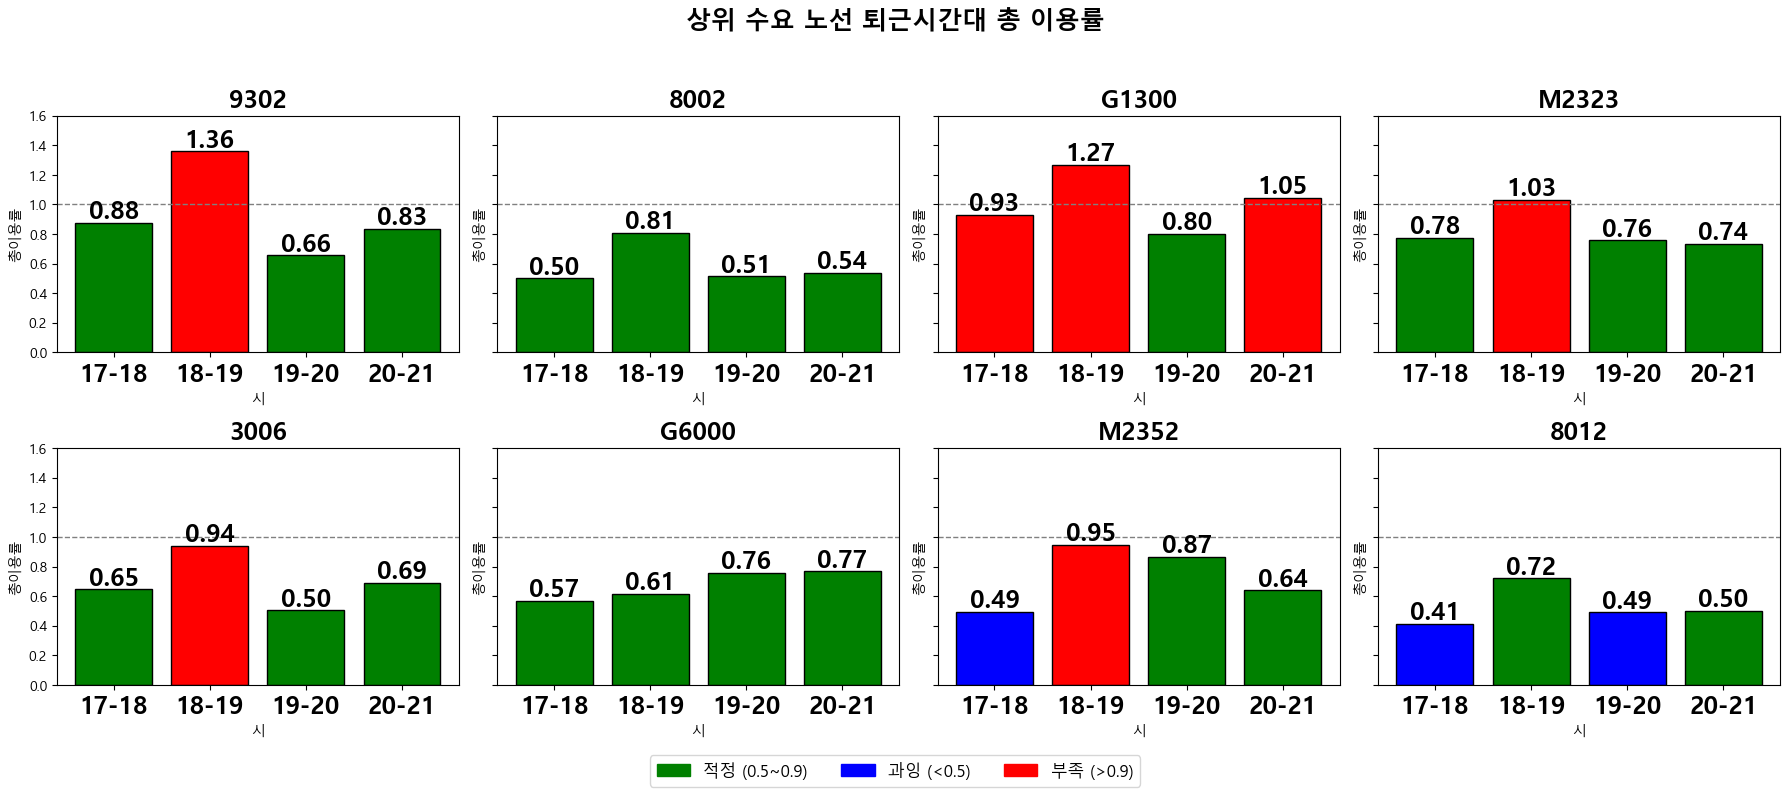

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
import numpy as np

# === 데이터 불러오기 ===
df = pd.read_csv(r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\주요노선_총이용률_현황.csv")

# === 주요 노선 목록 ===
main_routes = ['9302', '8002', 'G1300', 'M2323', '3006', 'G6000', 'M2352', '8012']

# === 주요 노선 필터링 ===
df = df[df['routeName'].astype(str).isin(main_routes)].copy()

# ======================================
# 🔥 time_bin → 시간대(17-18) 변환
# ======================================

def extract_hour(x):
    x = str(x)
    x = re.sub(r'[^0-9]', '', x)
    if x == "":
        return np.nan
    return int(x[:2])

df['hour_start'] = df['time_bin'].apply(extract_hour)
df['hour_end'] = df['hour_start'] + 1

# 최종 시간 라벨
df['time_label'] = df['hour_start'].astype(str) + "-" + df['hour_end'].astype(str)


# === 색상 매핑 ===
def judge_color(val):
    if val > 0.9:
        return 'red'      # 부족
    elif val < 0.5:
        return 'blue'     # 과잉
    else:
        return 'green'    # 적정 (0.5 이상 0.9 이하 포함)
df['color'] = df['총이용률'].apply(judge_color)

# === 시각화 ===
plt.rcParams['font.family'] = 'Malgun Gothic'
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
axes = axes.flatten()

for i, route in enumerate(main_routes):
    ax = axes[i]
    sub = df[df['routeName'] == route].copy()
    sub = sub.sort_values('hour_start')

    # 막대그래프
    ax.bar(sub['time_label'], sub['총이용률'], color=sub['color'], edgecolor='k')

    # 기준선
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)

    ax.set_title(f"{route}", fontsize=18, fontweight='bold')
    ax.set_ylim(0, max(1.6, sub['총이용률'].max()+0.1))
    ax.set_xlabel('시')
    ax.set_ylabel('총이용률')
    ax.set_xticklabels(sub['time_label'], fontsize=18, fontweight='bold')


    # 막대 위 텍스트
    for x, y in zip(sub['time_label'], sub['총이용률']):
        ax.text(x, y+0.03, f"{y:.2f}", ha='center', fontsize=18, fontweight='bold')

# === 전체 제목 + 범례 ===
fig.suptitle('상위 수요 노선 퇴근시간대 총 이용률', fontsize=18, fontweight='bold')

patches = [
    mpatches.Patch(color='green', label='적정 (0.5~0.9)'),
    mpatches.Patch(color='blue', label='과잉 (<0.5)'),
    mpatches.Patch(color='red', label='부족 (>0.9)')
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


### 정수계획 기반 혼잡완화형 버스 재배치 모델

In [15]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np

# ======================================
# 1) 파일 경로 입력
# ======================================
PATH_ARR = r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\도시 빅데이터 분석\찐 잠실\output\10월평일\10.17 최종파일\bus_arrival_detected.csv"
PATH_DEM = r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\버스투입평가.csv"

# 파라미터
CAP_1F = 44
CAP_2F = 70
TARGET_UTIL = 0.9
DONOR_MAX = 0.9
MAIN_ROUTES = ['9302','8002','G1300','M2323','3006','G6000','M2352','8012']

def to_time_bin(ts):
    h = ts.hour
    return f"{h:02d}:00-{(h+1)%24:02d}:00"


# ======================================
# 2) 데이터 로드
# ======================================
arr = pd.read_csv(PATH_ARR)
arr['timestamp'] = pd.to_datetime(arr['timestamp'])
arr['routeName'] = arr['routeName'].astype(str)
arr['time_bin'] = arr['timestamp'].apply(to_time_bin)

dem = pd.read_csv(PATH_DEM)
dem['routeName'] = dem['routeName'].astype(str)

# ======================================
# plate 번호 컬럼 자동 탐색 + 표준화
# ======================================
possible_plate_cols = ['plateNo1','plateNo','plate_no','bus_plate','vehicleNo','plateNumber','plate_no1']
real_plate_col = None

for col in possible_plate_cols:
    if col in arr.columns:
        real_plate_col = col
        break

if real_plate_col is None:
    raise ValueError(f"plate 번호 컬럼을 찾을 수 없습니다. CSV 컬럼 목록: {arr.columns.tolist()}")

arr = arr.rename(columns={real_plate_col: "plateNo1"})

# 주요 노선만 필터링
arr = arr[arr['routeName'].isin(MAIN_ROUTES)]
dem = dem[dem['routeName'].isin(MAIN_ROUTES)]


# ======================================
# 3) 실제 투입대수·좌석공급 계산
# ======================================
fleet = arr.groupby(
    ['routeName','time_bin','bus_type'],
    as_index=False
).agg(num=('plateNo1','nunique'))

pivot = fleet.pivot_table(
    index=['routeName','time_bin'],
    columns='bus_type',
    values='num',
    fill_value=0
).reset_index()

pivot.columns = [str(c) for c in pivot.columns]

# 🔥 pivot에 없는 컬럼 강제 생성
if '1층' not in pivot.columns:
    pivot['1층'] = 0
if '2층' not in pivot.columns:
    pivot['2층'] = 0

pivot = pivot.rename(columns={'1층':'num_1층','2층':'num_2층'})
pivot['seat_1층'] = pivot['num_1층'] * CAP_1F
pivot['seat_2층'] = pivot['num_2층'] * CAP_2F
pivot['total_seat'] = pivot['seat_1층'] + pivot['seat_2층']


# ======================================
# 4) 수요 데이터와 merge (여기서 충돌 해결)
# ======================================
base = dem.merge(
    pivot,
    how='left',
    on=['routeName','time_bin'],
    suffixes=('', '_pv')  # 🔥 충돌 방지
)

# 🔧 pivot 값을 실제 값으로 덮어쓰기
for c in ['num_1층','num_2층','seat_1층','seat_2층','total_seat']:
    if c + "_pv" in base.columns:
        base[c] = base[c + "_pv"]
    base[c] = base[c].fillna(0)


# ======================================
# 5) 이용률 계산
# ======================================
base['총이용률'] = np.where(base['total_seat'] > 0,
                         base['demand'] / base['total_seat'], np.nan)
base['1층이용률'] = np.where(base['seat_1층'] > 0,
                         base['demand'] / base['seat_1층'], np.nan)
base['2층이용률'] = np.where(base['seat_2층'] > 0,
                         base['demand'] / base['seat_2층'], np.nan)


# ======================================
# 6) 투입 판정
# ======================================
def judge_simple(row):
    util = row['총이용률']
    if row['total_seat'] == 0 or np.isnan(util):
        return "❌ 미투입"
    if util > 0.9:
        return "❌ 부족(증차)"
    if util < 0.5:
        return "⚠ 과잉(감차)"
    return "✅ 적정"

base['투입판정'] = base.apply(judge_simple, axis=1)


# ======================================
# 7) 출력 컬럼
# ======================================
cols_show = [
    'routeName','time_bin','demand',
    'num_1층','num_2층',
    'seat_1층','seat_2층','total_seat',
    '총이용률','1층이용률','2층이용률',
    '투입판정'
]

print("\n===== 전체 결과(상위 30행) =====")
print(base[cols_show].head(30).to_string(index=False))


# ======================================
# 8) 재배치 알고리즘
# ======================================
def recalc(row):
    total_seat = row['seat_1층'] + row['seat_2층']
    util = row['demand'] / total_seat if total_seat > 0 else np.inf
    return total_seat, util


def optimize_route(sub_df):
    sub = sub_df.copy().reset_index(drop=True)
    for c in ['num_1층','num_2층','seat_1층','seat_2층','total_seat']:
        sub[c] = sub[c].astype(float)

    moves = []
    improved = True

    while improved:
        improved = False

        needs = sub.index[sub['총이용률'] > TARGET_UTIL].tolist()
        donors = sub.index[sub['총이용률'] < 0.90].tolist()

        if not needs or not donors:
            break

        best = None

        for to_j in needs:
            dmd = sub.at[to_j, 'demand']
            for from_i in donors:
                if from_i == to_j:
                    continue

                for bus_type, cap, num_col, seat_col in [
                    ('1층', CAP_1F, 'num_1층', 'seat_1층'),
                    ('2층', CAP_2F, 'num_2층', 'seat_2층')
                ]:
                    if sub.at[from_i, num_col] <= 0:
                        continue

                    new_donor = sub.at[from_i, 'total_seat'] - cap
                    new_need  = sub.at[to_j, 'total_seat'] + cap

                    if new_donor <= 0:
                        continue

                    util_donor = sub.at[from_i, 'demand'] / new_donor
                    util_need  = dmd / new_need

                    if util_donor > DONOR_MAX:
                        continue
                    if util_need >= sub.at[to_j, '총이용률']:
                        continue

                    score = sub.at[to_j, '총이용률'] - util_need

                    if best is None or score > best[0]:
                        best = (score, from_i, to_j, bus_type, cap, num_col, seat_col)

        if best is None:
            break

        score, from_i, to_j, bus_type, cap, num_col, seat_col = best

        sub.at[from_i, num_col] -= 1
        sub.at[to_j, num_col] += 1
        sub.at[from_i, seat_col] -= cap
        sub.at[to_j, seat_col] += cap

        for idx in [from_i, to_j]:
            total_seat, util = recalc(sub.loc[idx])
            sub.at[idx, 'total_seat'] = total_seat
            sub.at[idx, '총이용률'] = util

        moves.append({
            "버스타입": bus_type,
            "감차시간": sub.at[from_i, 'time_bin'],
            "증차시간": sub.at[to_j, 'time_bin']
        })

        improved = True

    return sub, pd.DataFrame(moves)


# ======================================
# 9) 재배치 실행
# ======================================
final_list = []
move_list = []

for route, df_sub in base.groupby("routeName"):
    new_state, moves = optimize_route(df_sub)
    final_list.append(new_state)
    if not moves.empty:
        moves["routeName"] = route
        move_list.append(moves)

final_base = pd.concat(final_list, ignore_index=True)
moves_table = pd.concat(move_list, ignore_index=True) if move_list else pd.DataFrame()

print("\n===== 재배치 후 이용률 =====")
print(final_base[['routeName','time_bin','num_1층','num_2층','total_seat','demand','총이용률']]
      .sort_values(['routeName','time_bin'])
      .to_string(index=False))

print("\n===== 이동 로그 =====")
print(moves_table.to_string(index=False))


# ======================================
# 10) 파일 저장
# ======================================
final_base.to_csv(r"C:\Users\금경훈\Desktop\재배치_after_final.csv", index=False, encoding="utf-8-sig")
moves_table.to_csv(r"C:\Users\금경훈\Desktop\재배치_moves.csv", index=False, encoding="utf-8-sig")

print("\n💾 저장 완료!")



===== 전체 결과(상위 30행) =====
routeName    time_bin  demand  num_1층  num_2층  seat_1층  seat_2층  total_seat     총이용률    1층이용률    2층이용률     투입판정
     3006 17:00-18:00     142     5.0     0.0    220.0      0.0       220.0 0.645455 0.645455      NaN     ✅ 적정
     3006 18:00-19:00     190     3.0     1.0    132.0     70.0       202.0 0.940594 1.439394 2.714286 ❌ 부족(증차)
     3006 19:00-20:00     133     6.0     0.0    264.0      0.0       264.0 0.503788 0.503788      NaN     ✅ 적정
     3006 20:00-21:00     121     4.0     0.0    176.0      0.0       176.0 0.687500 0.687500      NaN     ✅ 적정
     8002 17:00-18:00     276     3.0     6.0    132.0    420.0       552.0 0.500000 2.090909 0.657143     ✅ 적정
     8002 18:00-19:00     318     1.0     5.0     44.0    350.0       394.0 0.807107 7.227273 0.908571     ✅ 적정
     8002 19:00-20:00     257     5.0     4.0    220.0    280.0       500.0 0.514000 1.168182 0.917857     ✅ 적정
     8002 20:00-21:00     249     1.0     6.0     44.0    420.0       464.0 0

### 재배치 이후 총 이용률

C:\Users\금경훈\AppData\Local\Temp\ipykernel_22804\1183281601.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub['time_label'], fontsize=15, fontweight='bold')
C:\Users\금경훈\AppData\Local\Temp\ipykernel_22804\1183281601.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub['time_label'], fontsize=15, fontweight='bold')
C:\Users\금경훈\AppData\Local\Temp\ipykernel_22804\1183281601.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub['time_label'], fontsize=15, fontweight='bold')
C:\Users\금경훈\AppData\Local\Temp\ipykernel_22804\1183281601.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set

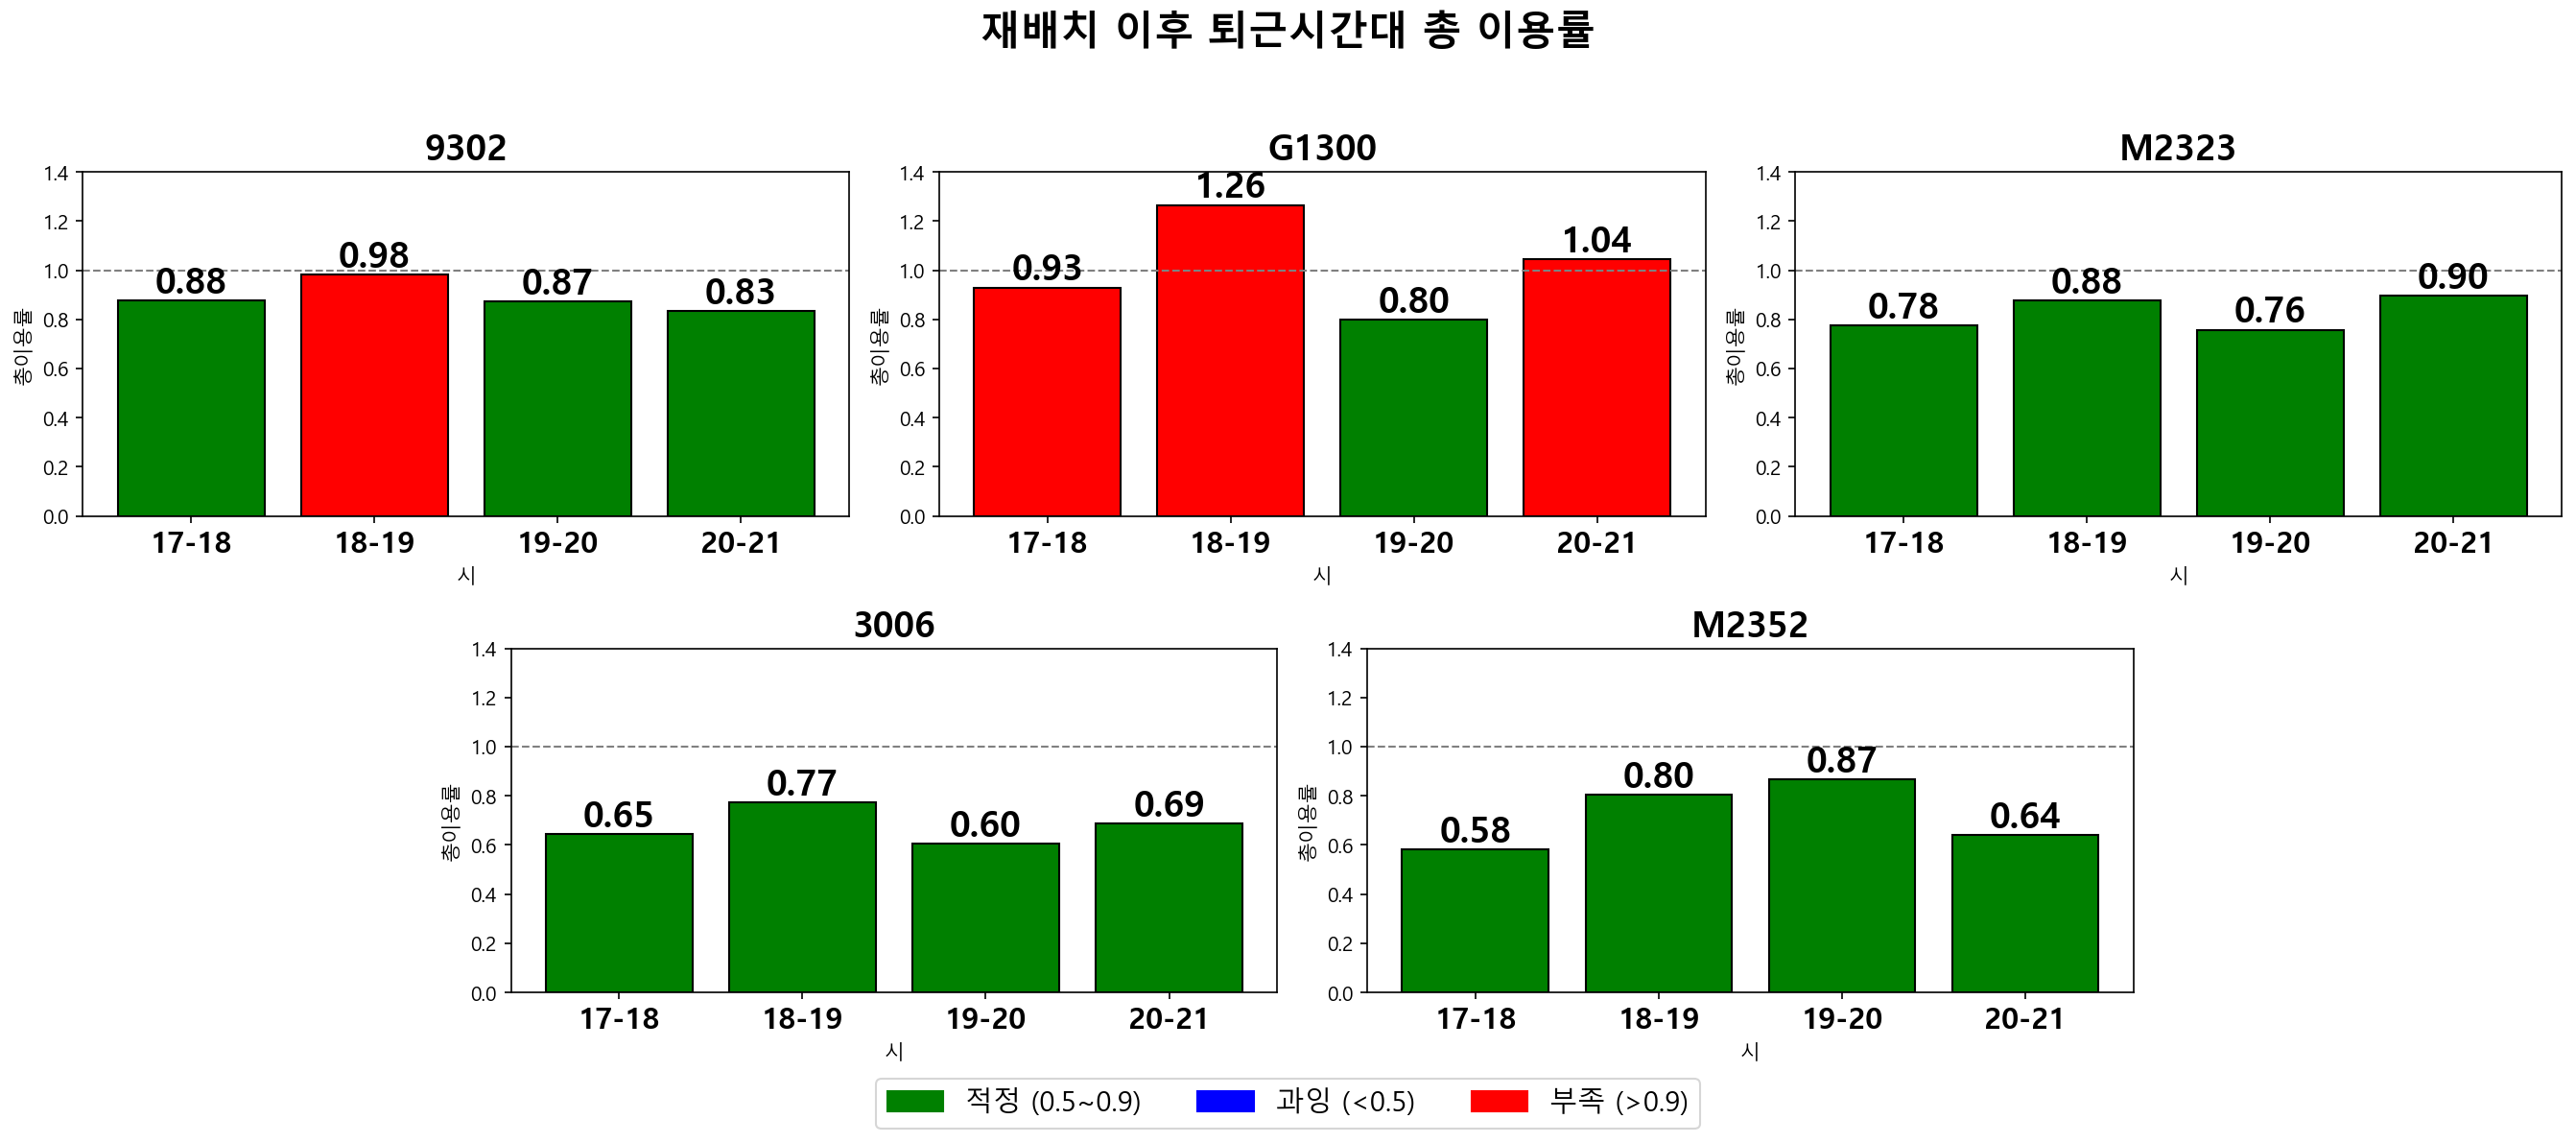

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import re

# =============================
# 1) 재배치 이후 데이터 불러오기
# =============================
df_after = pd.read_csv(r"C:\Users\금경훈\Desktop\Gachon\2-2\새 폴더\재배치_after_final_base.csv")

# 이번 그림에 포함할 5개 노선
routes_5 = ['9302', 'G1300', 'M2323', '3006', 'M2352']
df_after = df_after[df_after['routeName'].astype(str).isin(routes_5)].copy()

# =============================
# 2) time_bin → "17-18" 변환
# =============================
def extract_hour(x):
    x = str(x)
    nums = re.findall(r'\d+', x)
    if len(nums) == 0:
        return np.nan
    return int(nums[0])  # 17:00-18:00 → 17

df_after['hour_start'] = df_after['time_bin'].apply(extract_hour)
df_after['hour_end'] = df_after['hour_start'] + 1
df_after['time_label'] = df_after['hour_start'].astype(str) + "-" + df_after['hour_end'].astype(str)

# =============================
# 3) 색상 규칙 정의
# =============================
def judge_color(val):
    if val > 0.9:
        return 'red'        # 부족
    elif val < 0.5:
        return 'blue'       # 과잉
    else:
        return 'green'      # 적정

df_after['color'] = df_after['총이용률'].apply(judge_color)

# =============================
# 4) Figure 생성 (위 3개, 아래 2개 중앙 배치)
# =============================
plt.rcParams['font.family'] = 'Malgun Gothic'
fig = plt.figure(figsize=(18, 8), dpi=150)
gs = gridspec.GridSpec(2, 6, figure=fig)

axes = []
axes.append(fig.add_subplot(gs[0, 0:2]))  # 9302
axes.append(fig.add_subplot(gs[0, 2:4]))  # G1300
axes.append(fig.add_subplot(gs[0, 4:6]))  # M2323
axes.append(fig.add_subplot(gs[1, 1:3]))  # 3006 (중앙으로)
axes.append(fig.add_subplot(gs[1, 3:5]))  # M2352 (중앙으로)

route_order = ['9302', 'G1300', 'M2323', '3006', 'M2352']

# =============================
# 5) 각 서브플롯 그리기
# =============================
bars_dict = {}

for ax, route in zip(axes, route_order):
    sub = df_after[df_after['routeName'] == route].copy()
    sub = sub.sort_values('hour_start')

    bars = ax.bar(sub['time_label'], sub['총이용률'], 
                  color=sub['color'], edgecolor='k')
    bars_dict[route] = bars

    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)

    ax.set_title(route, fontsize=18, fontweight='bold')
    ax.set_ylim(0, max(1.4, sub['총이용률'].max() + 0.1))
    ax.set_xlabel('시')
    ax.set_ylabel('총이용률')
    ax.set_xticklabels(sub['time_label'], fontsize=15, fontweight='bold')

    for x, y in zip(sub['time_label'], sub['총이용률']):
        ax.text(x, y + 0.03, f"{y:.2f}", 
                ha='center', fontsize=18, fontweight='bold')

# =============================
# 6) 전체 제목 + 범례
# =============================
fig.suptitle('재배치 이후 퇴근시간대 총 이용률', fontsize=20, fontweight='bold')

legend_patches = [
    mpatches.Patch(color='green', label='적정 (0.5~0.9)'),
    mpatches.Patch(color='blue', label='과잉 (<0.5)'),
    mpatches.Patch(color='red', label='부족 (>0.9)')
]

fig.legend(handles=legend_patches, loc='lower center',
           ncol=3, fontsize=14)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()
